# Bays (2014) Figure 2 Equivalence

Model-only recreation (no human data). The Bays reference dataset is loaded from the shared cache at `experiments/cached_data/`, which is built once by the standalone script:

```
python -m experiments.bays_cache.build_bays_cache
```

The cache filename encodes every Bays generating parameter (omega, gamma_total, M, N_trials, seed). Notebooks read whichever cache matches the `M` they request. If a requested cache is missing, the loader raises a `FileNotFoundError` telling you exactly which builder command to run.

## Notebook structure

The two **main experiments** are at the top, each with its own one-cell experiment control:

1. **GP-to-Bays Fit** — fits one GP-side sampler family $(\lambda, \gamma, \sigma)$ to the cached Bays errors.
2. **Fixed-CV Sweep** — six $(\lambda, \gamma)$ fits, one at each CV value, against the same Bays cache. Gamma sampler only (CV is the Gamma-sampler's heterogeneity knob).

Each experiment has a control cell **immediately above** its core logic. Set `M` and `DISTRIBUTION` in that cell, run, save figures. The two experiments are independent — changing the control of one does not affect the other.

The remaining sections (single-subject sweep, GP-only 6-panel figure, GP-vs-Bays overlay, diagnostics, M-scaling probe) are kept for context but are downstream of the global configuration in Setup.


## Setup


### Imports


In [13]:
# Setup for the Notebook

import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import os
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter, NullLocator, FixedLocator
from matplotlib.colors import Normalize
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq, least_squares
from scipy.stats import vonmises

# GP framework
from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes
from core.decoder.ml_decoder import decode

# Circular-statistics helpers now live in core.population (they used to be
# imported from the ml decoder). population.py is the single source of truth
# for the per-trial error metric and the Fisher (1995) circular moments.
from core.population import (
    circular_error,
    circular_variance_fisher,
    circular_kurtosis_fisher,
)

# Bays cache loader — single source of truth for the comparison reference
from experiments.bays_cache import load_bays_cache, list_available_caches

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


### Circular Statistics


In [14]:
# Circular Statistics
#
# circular_variance_fisher / circular_kurtosis_fisher are imported from
# core.population (see Imports cell). The thin *_bays aliases preserve the
# names that downstream cells (e.g. the KDE-sweep diagnostic) still call.

circular_variance_bays = circular_variance_fisher   # sigma^2 = -2 log|m1|
circular_kurtosis_bays = circular_kurtosis_fisher   # Fisher (1995) kurtosis


def circular_moments(errors):
    """Variance (Fisher 1995 / Bays 2014) and kurtosis, plus mean resultant.

    Both moments are delegated to core.population so the notebook never
    diverges numerically from the library.
    """
    errors = np.asarray(errors, dtype=float)
    rho1 = float(np.abs(np.mean(np.exp(1j * errors))))
    return {
        'variance':       circular_variance_fisher(errors),
        'kurtosis':       circular_kurtosis_fisher(errors),
        'mean_resultant': rho1,
    }


def _direct_circular_variance(errors):
    """Independent reimplementation of sigma^2 = -2 log R.

    Used by the consistency diagnostic to confirm circular_moments() and a
    from-scratch computation agree to floating-point tolerance.
    """
    errors = np.asarray(errors, dtype=float)
    R = np.abs(np.mean(np.exp(1j * errors)))
    return float(-2.0 * np.log(max(R, 1e-15)))


def _kde_circular_variance(theta_grid, density):
    """Circular variance read off a KDE density curve sampled on theta_grid.

        R = | ∫ e^{iθ} p(θ) dθ | / ∫ p(θ) dθ ,   sigma^2 = -2 log R

    Diverges from the raw-sample variance when smoothing flattens long tails,
    which is exactly what the diagnostic is meant to surface.
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    density = np.asarray(density, dtype=float)
    Z = np.trapz(density, theta_grid)
    if Z <= 0:
        return np.nan
    m1 = np.trapz(density * np.exp(1j * theta_grid), theta_grid) / Z
    R = np.abs(m1)
    return float(-2.0 * np.log(max(R, 1e-15)))


def _estimate_von_mises_kappa(rho1):
    if rho1 < 1e-6:
        return 0.0
    if rho1 > 0.9999:
        return 700.0
    return brentq(lambda k: float(i1(k) / i0(k)) - rho1, 1e-4, 700.0)


def compute_deviation_from_normal(errors, n_bins=50):
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}

### Von Mises KDE


In [15]:
def vonmises_kde(data, eval_points, kappa):
    """
    Circular KDE using von Mises kernels.

    Parameters
    ----------
    data : array-like, shape (n,)
        Sample of angles in [−π, π).
    eval_points : array-like, shape (m,)
        Points at which to evaluate the density.
    kappa : float
        Concentration parameter of the von Mises kernel.
        Higher κ → narrower kernel (less smoothing).
        κ ≈ 1/h² where h is the Gaussian bandwidth equivalent.

    Returns
    -------
    density : ndarray, shape (m,)
    """
    data = np.asarray(data)
    eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]  # (m, n)
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm  # (m, n)
    density = np.exp(logsumexp(log_kernels, axis=1) - np.log(n))
    return density


# Bandwidth mapping: κ ≈ 1/h² (h = Gaussian bandwidth equivalent)
KAPPA_PANELS_AC = 25.0   # replaces bw_method=0.2
KAPPA_PANEL_E   = 44.0   # replaces bw_method=0.15

print(f'Von Mises KDE bandwidths: κ_ac={KAPPA_PANELS_AC}, κ_e={KAPPA_PANEL_E}')


Von Mises KDE bandwidths: κ_ac=25.0, κ_e=44.0


### Shared Constants

The Bays generating parameters, GP discretisation, KDE settings and the **single shared output folder** (`OUTPUT_DIR`) live here. These are fixed anchors used by every section.

**`M` and the distribution type are no longer global.** They are set per experiment, in the two control cells below: **GP-to-Bays Fit** (`M_FIT`, `DISTRIBUTION_FIT`) and **Fixed-CV Sweep** (`M_SWEEP`, `DISTRIBUTION_SWEEP`). Each control cell offers all three samplers: `folded_normal`, `gamma`, `sparse_broad`. Every figure from every section is written into the one `OUTPUT_DIR`, with M/distribution-tagged filenames.

In [ ]:
# === Shared constants (NOT experiment controls) ===
# M and the distribution type are NOT set here. They are controlled
# per experiment, in the GP-to-Bays Fit and Fixed-CV Sweep control cells.
# Everything below is a fixed anchor shared by every section.

# --- Bays generating parameters (anchor for the cache) ---
OMEGA_BAYS       = 0.52            # group-mean ML tuning width (Fig 2b)
GAMMA_TOTAL_BAYS = 119.0           # group-mean ML total gain, Hz (Fig 2b)
T_D              = 0.1             # decoding window, seconds
SET_SIZES        = [1, 2, 4, 8]    # set sizes to compare
SEED             = 12345           # base seed (anchors the cache identity)
LAMBDA_BASE      = np.sqrt(OMEGA_BAYS)   # M-independent

# --- GP discretisation and noise ---
N_THETA          = 128
SIGMA_SQ         = 1e-6

# --- Histogram / KDE / multi-seed sweep defaults ---
N_BINS           = 50
KAPPA_PANELS_AC  = 25.0
KAPPA_PANEL_E    = 44.0
KAPPA_BAYS_AC    = 80.0
N_SEEDS          = 5

# --- ONE shared output directory for the whole run ---------------------
# Every figure from every section (GP-to-Bays Fit, Fixed-CV Sweep, and the
# downstream diagnostics) is written into this single folder under
# result_data/. The per-figure filenames carry their own M / distribution
# tags so Fit and Sweep outputs never collide.
    _now = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULT_BASE = Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
    OUTPUT_DIR  = RESULT_BASE / f'figure_2_{_now}'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('=== Shared constants ===')
print(f'  omega       = {OMEGA_BAYS}')
print(f'  gamma_total = {GAMMA_TOTAL_BAYS} Hz')
print(f'  lambda      = sqrt(omega) = {LAMBDA_BASE:.4f}')
print(f'  set sizes   = {SET_SIZES}')
print(f'  seed        = {SEED}')
print(f'  OUTPUT_DIR  = {OUTPUT_DIR}   (single shared folder)')
print('  M and distribution are set per experiment, below.')

# --- Discover what Bays caches are on disk (informational) ---
_available = list_available_caches()
if _available:
    print(f'\nBays caches on disk:')
    for m_av, n_av, fn in _available:
        print(f'  M={m_av:>5}, N_trials={n_av:>5}   {fn}')
else:
    print('\nWARNING: no Bays caches on disk. Run:')
    print('  python -m experiments.bays_cache.build_bays_cache')


=== Shared constants ===
  omega       = 0.52
  gamma_total = 119.0 Hz
  lambda      = sqrt(omega) = 0.7211
  set sizes   = [1, 2, 4, 8]
  seed        = 12345
  OUTPUT_DIR  = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_20260622_140448   (single shared folder)
  M and distribution are set per experiment, below.

Bays caches on disk:
  M=  100, N_trials=10000   bays_cache_omega0.52_gamma119_M100_N10000_seed12345.npz
  M= 1000, N_trials=10000   bays_cache_omega0.52_gamma119_M1000_N10000_seed12345.npz
  M=10000, N_trials=10000   bays_cache_omega0.52_gamma119_M10000_N10000_seed12345.npz


### GP Framework

Population builder and vectorised trial engine for the Gaussian-Process variant. The trial engine draws true orientations continuously from $\mathrm{Uniform}[-\pi, \pi)$ and linearly interpolates the stored tuning curves at those off-grid points, eliminating the error-distribution quantization artefact that arises when truth and decoder both live on the same grid (see Diagnostics section).


In [17]:
# === GP population generator ===
# Wraps generate_neuron_population so the notebook can build a GP
# population in one line. The sampler is passed through as 'method'.
# The sparse_broad knobs (n_high, high_multiplier) are forwarded ONLY
# when that sampler is selected, so folded_normal / gamma calls are
# unchanged.

def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42,
                        lengthscale_variability=0.0,
                        gain_variability=0.0,
                        sampler='folded_normal',
                        n_high=1, high_multiplier=3.0):
    sb_kwargs = (dict(n_high=n_high, high_multiplier=high_multiplier)
                 if sampler == 'sparse_broad' else {})
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale,
        lengthscale_variability=lengthscale_variability,
        seed=seed,
        gain_variability=gain_variability,
        method=sampler,
        **sb_kwargs,
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M)])
             for loc in range(n_locations)]
    return thetas, f_all


In [18]:
# === Vectorised multi-location trial engine (continuous-θ encoding) ===
# True orientations are drawn from Uniform[-pi, pi) and the stored tuning
# curves are linearly interpolated at those off-grid points. See the
# Diagnostics section for the quantization story this avoids.

def _circular_linear_interp_indices(theta_continuous, n_theta):
    """
    Bracketing-grid indices and weights for linear interpolation of a
    function tabulated on the circular grid

        grid = np.linspace(-pi, pi, n_theta, endpoint=False)

    at continuous theta values. Returns (i0, i1, w) where
    f(theta) ≈ (1 - w) * f[grid[i0]] + w * f[grid[i1]].
    """
    theta_continuous = np.asarray(theta_continuous, dtype=float)
    spacing = 2.0 * np.pi / n_theta
    idx_f = (theta_continuous + np.pi) / spacing
    i0_float = np.floor(idx_f)
    i0 = i0_float.astype(np.intp) % n_theta
    i1 = (i0 + 1) % n_theta
    w = idx_f - i0_float
    return i0, i1, w


def run_multiloc_trials(f_all, thetas, active_locs, cued_index,
                        gamma, T_d, sigma_sq, n_trials, rng, batch_size=1000):
    """
    Vectorised multi-location trial engine.

    Encoding and spiking are vectorised across batches; decoding goes
    through core.decoder.ml_decoder.decode(); per-trial error uses
    core.population.circular_error (imported in the Setup cell).
    """
    n_locs = len(active_locs)
    M_neurons, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in active_locs]
    errors = np.empty(n_trials)

    # Continuous true orientations (no encoding-grid quantization)
    all_theta_continuous = rng.uniform(-np.pi, np.pi, size=(n_trials, n_locs))
    all_i0, all_i1, all_w = _circular_linear_interp_indices(
        all_theta_continuous, n_theta
    )

    for start in range(0, n_trials, batch_size):
        end = min(start + batch_size, n_trials)
        B = end - start
        i0_b = all_i0[start:end]
        i1_b = all_i1[start:end]
        w_b  = all_w [start:end]

        # Linear interpolation between bracketing grid points
        log_r_pre = np.zeros((M_neurons, B))
        for k in range(n_locs):
            f_left  = f_active[k][:, i0_b[:, k]]
            f_right = f_active[k][:, i1_b[:, k]]
            log_r_pre += (1.0 - w_b[:, k]) * f_left + w_b[:, k] * f_right
        r_pre = np.exp(log_r_pre)

        # DN
        D = sigma_sq + np.mean(r_pre, axis=0)
        rates = gamma * r_pre / D[np.newaxis, :]

        # Poisson
        counts = rng.poisson(rates * T_d)

        # Per-trial decoding via core method (still grid-based)
        for b in range(B):
            n_vec = counts[:, b]
            theta_hat, _ = decode(n_vec, f_active, thetas, cued_index)
            theta_true = all_theta_continuous[start + b, cued_index]
            errors[start + b] = circular_error(theta_true, theta_hat)

    return errors


## GP-to-Bays Fit (3 Free Parameters)

Fits one GP-side sampler family $(\lambda, \gamma, \sigma)$ to the cached Bays errors. The `M` and `DISTRIBUTION` flags in the experiment-control cell below override the global configuration *for this experiment only* — the rest of the notebook still uses the global flags.

`DISTRIBUTION` chooses how lengthscales are sampled across locations inside the GP forward model:

| Value | Sampler | $\sigma$ semantics |
|---|---|---|
| `'folded_normal'` | $\lambda_i = \lambda_\mathrm{base}\,\lvert 1 + \sigma \cdot z_i \rvert$, $z_i \sim \mathcal{N}(0,1)$ | unitless standard deviation, $\sigma \geq 0$ |
| `'gamma'` | $\lambda_i \sim \mathrm{Gamma}$ with mean $\lambda_\mathrm{base}$ and CV $\sigma$ | coefficient of variation, $\sigma > 0$ |

The optimization procedure is identical for both samplers — only the forward model differs. Results are saved into `figure_2_M{M}_{distribution}_{timestamp}/`.


In [19]:
# === EXPERIMENT 1 CONTROL — set M and distribution for the GP-to-Bays Fit ===
# This is one of only two control points in the notebook (the other is the
# Fixed-CV Sweep). Set M and the distribution here.
#
#   M:            100 (fast, primary) / 1000 / 10000  (must match a Bays cache)
#   DISTRIBUTION: 'folded_normal' | 'gamma' | 'sparse_broad'
M_FIT            = 1000
DISTRIBUTION_FIT = 'sparse_broad'

# --- sparse_broad sampler knobs (ignored unless DISTRIBUTION_FIT='sparse_broad') ---
N_HIGH_FIT          = 1      # number of broad-tuning locations per neuron
HIGH_MULTIPLIER_FIT = 3.0    # broad-component lengthscale multiplier

assert DISTRIBUTION_FIT in ('folded_normal', 'gamma', 'sparse_broad'), (
    f"DISTRIBUTION_FIT must be folded_normal / gamma / sparse_broad, "
    f"got {DISTRIBUTION_FIT!r}"
)

# All figures go into the single shared run folder (OUTPUT_DIR); filenames
# carry the M / distribution tag so this experiment's outputs are distinct.
FIT_OUTPUT_DIR = OUTPUT_DIR

print(f'=== GP-to-Bays Fit experiment ===')
print(f'  M            = {M_FIT}')
print(f'  DISTRIBUTION = {DISTRIBUTION_FIT!r}')
if DISTRIBUTION_FIT == 'sparse_broad':
    print(f'  N_HIGH_FIT          = {N_HIGH_FIT}')
    print(f'  HIGH_MULTIPLIER_FIT = {HIGH_MULTIPLIER_FIT}')
print(f'  Output       = {FIT_OUTPUT_DIR}   (shared run folder)')

# Load the Bays cache at this experiment's M.
fit_bays_errors, fit_bays_meta = load_bays_cache(
    M=M_FIT, N_trials=10000,
    omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, seed=SEED,
)
print(f'  Bays cache:   {fit_bays_meta["cache_filename"]}')


=== GP-to-Bays Fit experiment ===
  M            = 1000
  DISTRIBUTION = 'sparse_broad'
  N_HIGH_FIT          = 1
  HIGH_MULTIPLIER_FIT = 3.0
  Output       = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_20260622_140448   (shared run folder)
  Bays cache:   bays_cache_omega0.52_gamma119_M1000_N10000_seed12345.npz


In [20]:
# === Fit configuration: optimizer setup driven by EXPERIMENT 1 CONTROL ===
N_DATA       = 10000   # MUST equal the cache's trial count
N_TRIALS_FIT = 1000    # GP forward-model trials per evaluation
SEED_FIT     = SEED    # anchor for fit-side seeds

# Histogram grid for the residual
N_BINS_FIT  = 50
BIN_EDGES   = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# Starting points and bounds depend on the chosen sampler. Gamma requires
# CV strictly > 0 (undefined at CV=0); folded-Normal allows sigma=0 cleanly.
if DISTRIBUTION_FIT == 'folded_normal':
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.0]
    HI = [3.0, 10.0, 2.0]
    SIGMA_TARGET = 0.0     # Bays is homogeneous; we expect sigma -> 0
    SIGMA_NAME   = 'sigma_lambda'
else:  # 'gamma' or 'sparse_broad' (both use a strictly-positive CV-like knob)
    X0 = [1.0, 2.0, 0.5]
    LO = [0.1, 0.1, 0.01]
    HI = [3.0, 10.0, 10.0]
    SIGMA_TARGET = 0.01    # near the lower bound; Bays is homogeneous
    SIGMA_NAME   = 'cv'

DIFF_STEP = 0.05

# Recovery targets
LAMBDA_TARGET = np.sqrt(OMEGA_BAYS)
GAMMA_TARGET  = GAMMA_TOTAL_BAYS / M_FIT

print(f'Optimizer configuration  (M={M_FIT}, distribution={DISTRIBUTION_FIT}):')
print(f'  x0     = {X0}  (lambda, gamma, {SIGMA_NAME})')
print(f'  bounds = ({LO}, {HI})')
print(f'  Recovery targets: lambda={LAMBDA_TARGET:.4f}, '
      f'gamma={GAMMA_TARGET:.4f}, {SIGMA_NAME}=~{SIGMA_TARGET}')

# Build the fit-target vector from the cached Bays errors
data_errors = fit_bays_errors   # bind to the cache loaded in the experiment cell
data_hists  = {}
for N in SET_SIZES:
    h, _ = np.histogram(data_errors[N], bins=BIN_EDGES, density=True)
    data_hists[N] = h
data_vector = np.concatenate([data_hists[N] for N in SET_SIZES])
print(f'  Data vector shape: {data_vector.shape}')


Optimizer configuration  (M=1000, distribution=sparse_broad):
  x0     = [1.0, 2.0, 0.5]  (lambda, gamma, cv)
  bounds = ([0.1, 0.1, 0.01], [3.0, 10.0, 10.0])
  Recovery targets: lambda=0.7211, gamma=0.1190, cv=~0.01
  Data vector shape: (200,)


In [21]:
# In Cell 9, alongside N_THETA / SIGMA_SQ etc.
GAIN_VARIABILITY = 0.0

In [22]:
# === Unified fit: dispatches on DISTRIBUTION_FIT ===
# Same procedure (least_squares on histogram residuals) regardless of sampler;
# only the forward model's 'method' kwarg differs.

def gp_forward(lambda_base, gamma_per_neuron, sigma, seed=0):
    """Build a GP population and run the multi-location trial engine,
    returning a histogram vector concatenated across set sizes."""
    max_locs = max(SET_SIZES)
    _sb = (dict(n_high=N_HIGH_FIT, high_multiplier=HIGH_MULTIPLIER_FIT)
           if DISTRIBUTION_FIT == 'sparse_broad' else {})
    population = generate_neuron_population(
        n_neurons=M_FIT, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lambda_base,
        lengthscale_variability=sigma,
        seed=seed,
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION_FIT,
        **_sb,
    )
    thetas = population[0]['orientations']
    f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(M_FIT)])
             for loc in range(max_locs)]

    pred_hists = []
    for N in SET_SIZES:
        rng = np.random.RandomState(seed + N)
        errs = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
        pred_hists.append(h)
    return np.concatenate(pred_hists)


def residual(params):
    lam, gam, sig = params
    return data_vector - gp_forward(lam, gam, sig, seed=SEED_FIT)


print(f'Running fit  (M={M_FIT}, distribution={DISTRIBUTION_FIT})...')
t0 = time.time()
result = least_squares(
    residual, x0=X0, bounds=(LO, HI),
    method='trf', diff_step=DIFF_STEP, verbose=2,
)
print(f'Fit completed in {time.time()-t0:.1f}s')

# Unpack
lambda_hat, gamma_hat, sigma_lambda_hat = result.x
omega_hat       = lambda_hat ** 2
gamma_total_hat = gamma_hat * M_FIT
SIGMA_LAMBDA_TARGET = SIGMA_TARGET   # alias for the plot cell that follows

print(f'\n=== {DISTRIBUTION_FIT.replace("_", "-").title()} fit results ===')
print(f'  lambda_hat       = {lambda_hat:.4f}   (target {LAMBDA_TARGET:.4f})')
print(f'  gamma_hat        = {gamma_hat:.4f}    (target {GAMMA_TARGET:.4f})')
print(f'  {SIGMA_NAME}_hat = {sigma_lambda_hat:.4f}    (target ~ {SIGMA_TARGET})')
print(f'  -> omega_hat     = {omega_hat:.4f}    (Bays {OMEGA_BAYS})')
print(f'  -> gamma_total   = {gamma_total_hat:.1f} Hz  (Bays {GAMMA_TOTAL_BAYS})')
print(f'  cost             = {result.cost:.6f}')

# Final predictions for plotting
fitted_errors = {}
fitted_hists  = {}
max_locs = max(SET_SIZES)
_sb_fit = (dict(n_high=N_HIGH_FIT, high_multiplier=HIGH_MULTIPLIER_FIT)
           if DISTRIBUTION_FIT == 'sparse_broad' else {})
population_fit = generate_neuron_population(
    n_neurons=M_FIT, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=lambda_hat,
    lengthscale_variability=sigma_lambda_hat,
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    method=DISTRIBUTION_FIT,
    **_sb_fit,
)
thetas_fit = population_fit[0]['orientations']
f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(M_FIT)])
              for loc in range(max_locs)]
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 7000 + N)
    errs = run_multiloc_trials(
        f_all_fit, thetas_fit, tuple(range(N)), 0,
        gamma_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    fitted_errors[N] = errs
    h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
    fitted_hists[N] = h
    m = circular_moments(errs)
    print(f'  fitted N={N}: var={m["variance"]:.4f}  kurt={m["kurtosis"]:.3f}')

# Make fitted_errors_gamma a downstream alias regardless of which sampler
# was used. The Diagnostics cells reference this name; with the unified
# fit, "_gamma" is a misnomer but the alias keeps those cells working
# without modification.
fitted_errors_gamma = fitted_errors


Running fit  (M=1000, distribution=sparse_broad)...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.3259e+01                                    5.11e+01    
       1              2         1.6104e+01      7.15e+00       7.44e-01       1.23e+01    
       2              3         1.3860e+01      2.24e+00       8.38e-02       3.52e+01    
       3              4         1.0595e+01      3.26e+00       2.38e-01       3.08e+01    
       4             17         1.0595e+01      0.00e+00       0.00e+00       3.08e+01    
`xtol` termination condition is satisfied.
Function evaluations 17, initial cost 2.3259e+01, final cost 1.0595e+01, first-order optimality 3.08e+01.
Fit completed in 1192.6s

=== Sparse-Broad fit results ===
  lambda_hat       = 1.2407   (target 0.7211)
  gamma_hat        = 1.1225    (target 0.1190)
  cv_hat = 0.3940    (target ~ 0.01)
  -> omega_hat     = 1.5395    (Bays 0.52)
  -> gamma_total   = 

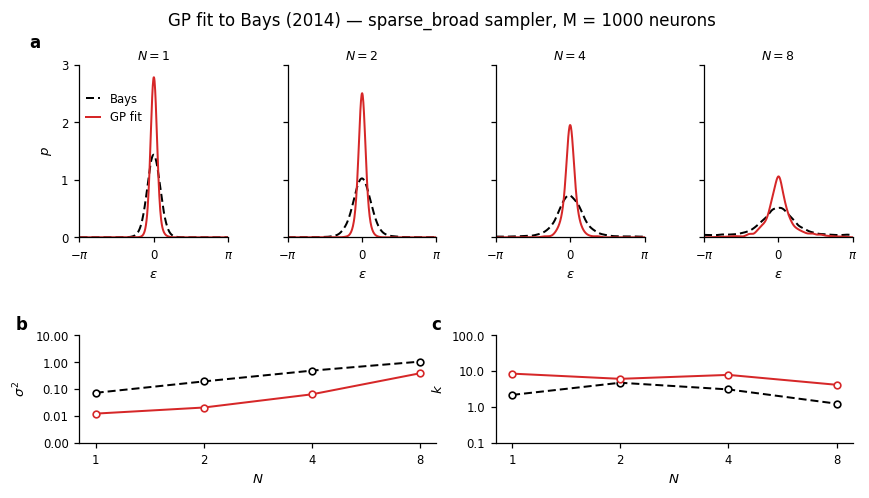

In [23]:
# === Plot: fitted GP (red) vs Bays-generated data (black, dashed) ===
# Fixes vs previous version:
#   * M_FIT now shown in the title.
#   * N-label moved off the curve peak (was colliding in the N=8 panel);
#     wspace tightened so panels sit closer.
#   * Bottom row (b, c) made shorter via height_ratios + wider via wspace,
#     shrinking its aspect ratio.
#   * Variance/kurtosis y-limits are now DATA-DRIVEN (with padding) instead
#     of a hard-coded (0.01, 10) window, so the panel-c lines no longer
#     drop off the bottom of the axis and vanish.

import matplotlib as mpl
from matplotlib.ticker import (
    ScalarFormatter, NullLocator, FixedLocator, MaxNLocator, LogLocator,
)

NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference

theta_smooth_fit = np.linspace(-np.pi, np.pi, 500)

KDE_YTICKS = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Symmetric-in-log padding around the actual data range.

    Replaces the old hard-coded (0.01, 10) window that clipped the
    kurtosis lines. Guards against non-positive values before logging.
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return 0.01, 10.0
    lo_exp = np.floor(np.log10(v.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(v.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp


def _auto_log_y(ax, lo, hi):
    """Decade major ticks across [lo, hi]; labelled, no minor ticks."""
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


with mpl.rc_context(NATURE_STYLE):
    # ---- Geometry ----
    # Taller figure + height_ratios make row 2 shorter than row 1, which
    # (combined with the 1+1 column span of b and c) shrinks the b/c
    # aspect ratio. wspace tightened so the KDE panels sit closer and the
    # N=8 panel is no longer jammed against the right edge.
    fig = plt.figure(figsize=(7.2, 4.2))
    gs = gridspec.GridSpec(
        2, len(SET_SIZES),
        height_ratios=[1.0, 0.62],
        hspace=0.70, wspace=0.40,
        left=0.08, right=0.975, bottom=0.13, top=0.88,
    )
    fig.suptitle(
        f'GP fit to Bays (2014) — {DISTRIBUTION_FIT} sampler, M = {M_FIT} neurons',
        fontsize=10, y=0.985,
    )

    # ---- precompute KDEs ----
    kdes_data = {N: vonmises_kde(data_errors[N],   theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}
    kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                 for N in SET_SIZES}

    peak = max(max(k.max() for k in kdes_data.values()),
               max(k.max() for k in kdes_fit.values()))
    kde_ymax   = peak * 1.08
    kde_yticks = _pick_kde_yticks(kde_ymax)

    # ---- Row 1: KDE overlays ----
    for i, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs[0, i])
        ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                linestyle=BAYS_LINESTYLE,
                label='Bays' if i == 0 else None)
        ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                label='GP fit' if i == 0 else None)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        ax.set_yticks(kde_yticks)
        ax.set_ylim(0, kde_ymax)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.set_xlabel(r'$\varepsilon$')
        # Set-size label moved to the upper-LEFT inset so it no longer
        # overlaps the (right-leaning) curve peak in the N=8 panel.
        ax.set_title(f'$N={N}$', fontsize=7.5, pad=3)

        if i == 0:
            ax.set_ylabel(r'$p$')
            ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                      borderaxespad=0.2, bbox_to_anchor=(0.0, 0.88))
            ax.text(-0.34, 1.18, 'a', transform=ax.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        _style_axes(ax)

    # ---- Row 2: variance and kurtosis vs set size ----
    var_bays  = np.array([circular_moments(data_errors[N])['variance']   for N in SET_SIZES])
    kurt_bays = np.array([circular_moments(data_errors[N])['kurtosis']   for N in SET_SIZES])
    var_fit   = np.array([circular_moments(fitted_errors[N])['variance'] for N in SET_SIZES])
    kurt_fit  = np.array([circular_moments(fitted_errors[N])['kurtosis'] for N in SET_SIZES])

    # gs[1, :2] / gs[1, 2:] splits 4 columns into 2+2.
    ax_var = fig.add_subplot(gs[1, :2])
    ax_var.plot(SET_SIZES, var_bays, marker='o', color=BAYS_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, *_data_driven_log_ylim(np.concatenate([var_bays, var_fit])))
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.text(-0.18, 1.18, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    ax_kurt = fig.add_subplot(gs[1, 2:])
    ax_kurt.plot(SET_SIZES, kurt_bays, marker='o', color=BAYS_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
    ax_kurt.plot(SET_SIZES, kurt_fit, marker='o', color=GP_COLOR,
                 lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_kurt.set_yscale('log')
    _setsize_log_axis(ax_kurt, SET_SIZES)
    # Data-driven limits keep the kurtosis lines on-canvas instead of
    # dropping below a fixed 0.01 floor.
    _auto_log_y(ax_kurt, *_data_driven_log_ylim(np.concatenate([kurt_bays, kurt_fit])))
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.18, 1.18, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    fig.savefig(FIT_OUTPUT_DIR / f'gp_fit_M{M_FIT}_{DISTRIBUTION_FIT}_overlay.png',
                dpi=300, bbox_inches='tight')
    fig.savefig(FIT_OUTPUT_DIR / f'gp_fit_M{M_FIT}_{DISTRIBUTION_FIT}_overlay.pdf',
                bbox_inches='tight')
    plt.show()

## Fixed-CV Sweep

At each CV value in `CV_VALUES`, fits only $(\lambda, \gamma)$ with CV held constant inside the forward model. Produces one fit per CV value, so we can see how recovery quality varies with the imposed level of lengthscale heterogeneity.

**Gamma sampler only.** CV is the Gamma sampler's heterogeneity knob; the folded-Normal sampler uses an unbounded $\sigma$ which doesn't translate cleanly. `DISTRIBUTION` for this experiment is therefore fixed at `'gamma'` and only `M` is free to choose.


In [24]:
# === EXPERIMENT 2 CONTROL — set M and distribution for the Fixed-CV Sweep ===
# Independent of the GP-to-Bays Fit: set this experiment's own M and
# distribution here. (CV is swept below; it is the sampler's heterogeneity
# knob, so the sweep is most meaningful for gamma / sparse_broad.)
#
#   M:            100 / 1000 / 10000  (must match a Bays cache)
#   DISTRIBUTION: 'folded_normal' | 'gamma' | 'sparse_broad'
M_SWEEP            = 1000
DISTRIBUTION_SWEEP = 'sparse_broad'

# --- sparse_broad sampler knobs (ignored unless DISTRIBUTION_SWEEP='sparse_broad') ---
N_HIGH_SWEEP          = 1
HIGH_MULTIPLIER_SWEEP = 3.0

assert DISTRIBUTION_SWEEP in ('folded_normal', 'gamma', 'sparse_broad'), (
    f"DISTRIBUTION_SWEEP must be folded_normal / gamma / sparse_broad, "
    f"got {DISTRIBUTION_SWEEP!r}"
)

# CV values to sweep over (log-spaced from near-homogeneous to heterogeneous).
CV_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# All figures go into the single shared run folder (OUTPUT_DIR); filenames
# carry the M / distribution tag so this experiment's outputs are distinct
# from the Fit's.
SWEEP_OUTPUT_DIR = OUTPUT_DIR

print(f'=== Fixed-CV Sweep experiment ===')
print(f'  M            = {M_SWEEP}')
print(f'  DISTRIBUTION = {DISTRIBUTION_SWEEP!r}')
if DISTRIBUTION_SWEEP == 'sparse_broad':
    print(f'  N_HIGH_SWEEP          = {N_HIGH_SWEEP}')
    print(f'  HIGH_MULTIPLIER_SWEEP = {HIGH_MULTIPLIER_SWEEP}')
print(f'  CV values:    {CV_VALUES}')
print(f'  Output       = {SWEEP_OUTPUT_DIR}   (shared run folder)')

# Load this experiment's own Bays cache at M_SWEEP (reuse the Fit's if it
# matches, to avoid a redundant disk read).
if 'fit_bays_errors' in globals() and globals().get('M_FIT') == M_SWEEP:
    sweep_bays_errors, sweep_bays_meta = fit_bays_errors, fit_bays_meta
else:
    sweep_bays_errors, sweep_bays_meta = load_bays_cache(
        M=M_SWEEP, N_trials=10000,
        omega=OMEGA_BAYS, gamma_total=GAMMA_TOTAL_BAYS, seed=SEED,
    )
print(f'  Bays cache:   {sweep_bays_meta["cache_filename"]}')


=== Fixed-CV Sweep experiment ===
  M            = 1000
  DISTRIBUTION = 'sparse_broad'
  N_HIGH_SWEEP          = 1
  HIGH_MULTIPLIER_SWEEP = 3.0
  CV values:    [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  Output       = /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_20260622_140448   (shared run folder)
  Bays cache:   bays_cache_omega0.52_gamma119_M1000_N10000_seed12345.npz


In [25]:
# === Fixed-CV sweep: one (lambda, gamma) fit per CV value ===
# Two-parameter fit at each fixed CV. The optimization procedure is the
# same as Experiment 1's main fit; only the forward model has CV pinned.

# Sweep-local bindings — kept distinct from Experiment 1's bindings so
# the two experiments don't trample each other's state.
_M_sweep         = M_SWEEP
N_TRIALS_FIT     = 1000
SEED_FIT         = SEED
N_BINS_FIT       = 50
BIN_EDGES        = np.linspace(-np.pi, np.pi, N_BINS_FIT + 1)

# Build fit-target vector from this experiment's Bays cache
sweep_data_hists = {}
for N in SET_SIZES:
    h, _ = np.histogram(sweep_bays_errors[N], bins=BIN_EDGES, density=True)
    sweep_data_hists[N] = h
sweep_data_vector = np.concatenate([sweep_data_hists[N] for N in SET_SIZES])

# Two-parameter fit setup (CV is fixed per run)
X0_FIXED  = [1.0, 2.0]
LO_FIXED  = [0.1, 0.1]
HI_FIXED  = [3.0, 10.0]
DIFF_STEP_FIXED = 0.05

print(f'Fixed-CV sweep  (M={_M_sweep}, distribution={DISTRIBUTION_SWEEP}): CV ∈ {CV_VALUES}')
print(f'  Per-CV fit: x0={X0_FIXED}, bounds=({LO_FIXED}, {HI_FIXED})')
print()

# Forward-model factory: builds a residual function with CV baked in
def make_residual(cv_fixed):
    def gp_forward_fixed(lambda_base, gamma_per_neuron, seed=0):
        max_locs = max(SET_SIZES)
        _sb = (dict(n_high=N_HIGH_SWEEP, high_multiplier=HIGH_MULTIPLIER_SWEEP)
               if DISTRIBUTION_SWEEP == 'sparse_broad' else {})
        population = generate_neuron_population(
            n_neurons=_M_sweep, n_orientations=N_THETA, n_locations=max_locs,
            base_lengthscale=lambda_base,
            lengthscale_variability=cv_fixed,
            seed=seed,
            gain_variability=GAIN_VARIABILITY,
            method=DISTRIBUTION_SWEEP,
            **_sb,
        )
        thetas = population[0]['orientations']
        f_all = [np.array([population[n]['f_samples'][loc, :] for n in range(_M_sweep)])
                 for loc in range(max_locs)]
        pred_hists = []
        for N in SET_SIZES:
            rng = np.random.RandomState(seed + N)
            errs = run_multiloc_trials(
                f_all, thetas, tuple(range(N)), 0,
                gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
            h, _ = np.histogram(errs, bins=BIN_EDGES, density=True)
            pred_hists.append(h)
        return np.concatenate(pred_hists)

    def residual_fn(params):
        lam, gam = params
        return sweep_data_vector - gp_forward_fixed(lam, gam, seed=SEED_FIT)

    return residual_fn, gp_forward_fixed


# Run one fit per CV value
sweep_results = {}
for cv in CV_VALUES:
    print(f'\n--- CV = {cv} ---')
    t0 = time.time()
    residual_fn, forward_fn = make_residual(cv)
    result = least_squares(
        residual_fn, x0=X0_FIXED, bounds=(LO_FIXED, HI_FIXED),
        method='trf', diff_step=DIFF_STEP_FIXED, verbose=0,
    )
    lam_hat, gam_hat = result.x
    print(f'  lambda_hat = {lam_hat:.4f},  gamma_hat = {gam_hat:.4f},  '
          f'cost = {result.cost:.4f},  time = {time.time()-t0:.1f}s')

    # Final predictions at the fitted (lambda, gamma) with this CV
    max_locs = max(SET_SIZES)
    _sb_cv = (dict(n_high=N_HIGH_SWEEP, high_multiplier=HIGH_MULTIPLIER_SWEEP)
              if DISTRIBUTION_SWEEP == 'sparse_broad' else {})
    population_fit = generate_neuron_population(
        n_neurons=_M_sweep, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=lam_hat,
        lengthscale_variability=cv,
        seed=SEED_FIT,
        gain_variability=GAIN_VARIABILITY,
        method=DISTRIBUTION_SWEEP,
        **_sb_cv,
    )
    thetas_fit = population_fit[0]['orientations']
    f_all_fit  = [np.array([population_fit[n]['f_samples'][loc, :] for n in range(_M_sweep)])
                  for loc in range(max_locs)]
    fitted_errors_per_cv = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 7000 + N)
        errs = run_multiloc_trials(
            f_all_fit, thetas_fit, tuple(range(N)), 0,
            gam_hat, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        fitted_errors_per_cv[N] = errs
    sweep_results[cv] = {
        'lambda_hat':    lam_hat,
        'gamma_hat':     gam_hat,
        'omega_hat':     lam_hat ** 2,
        'gamma_total':   gam_hat * _M_sweep,
        'cost':          result.cost,
        'fitted_errors': fitted_errors_per_cv,
    }

print('\n=== Sweep summary ===')
print(f'{"CV":>6}  {"λ̂":>8}  {"γ̂":>8}  {"ω̂":>8}  {"γ_total":>10}  {"cost":>8}')
for cv in CV_VALUES:
    r = sweep_results[cv]
    print(f'{cv:>6.2f}  {r["lambda_hat"]:>8.4f}  {r["gamma_hat"]:>8.4f}  '
          f'{r["omega_hat"]:>8.4f}  {r["gamma_total"]:>10.2f}  {r["cost"]:>8.4f}')

# Make the cached Bays errors visible under the names the downstream
# diagnostic/summary cells expect (both aliases point at this sweep's
# Bays cache).
bays_cached_errors = sweep_bays_errors
bays_errs = sweep_bays_errors


Fixed-CV sweep  (M=1000, distribution=sparse_broad): CV ∈ [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  Per-CV fit: x0=[1.0, 2.0], bounds=([0.1, 0.1], [3.0, 10.0])


--- CV = 0.1 ---
  lambda_hat = 1.4304,  gamma_hat = 1.6629,  cost = 5.9803,  time = 985.7s

--- CV = 0.5 ---
  lambda_hat = 1.2185,  gamma_hat = 1.2805,  cost = 15.6319,  time = 904.1s

--- CV = 1.0 ---
  lambda_hat = 1.6995,  gamma_hat = 1.1983,  cost = 16.7500,  time = 674.1s

--- CV = 2.0 ---
  lambda_hat = 1.0000,  gamma_hat = 2.0000,  cost = 22.8036,  time = 1510.2s

--- CV = 5.0 ---
  lambda_hat = 1.2840,  gamma_hat = 1.2934,  cost = 5.9576,  time = 438.2s

--- CV = 10.0 ---
  lambda_hat = 1.2449,  gamma_hat = 1.9349,  cost = 3.7948,  time = 662.5s

=== Sweep summary ===
    CV        λ̂        γ̂        ω̂     γ_total      cost
  0.10    1.4304    1.6629    2.0459     1662.91    5.9803
  0.50    1.2185    1.2805    1.4847     1280.49   15.6319
  1.00    1.6995    1.1983    2.8882     1198.30   16.7500
  2.00    1.0000    2.000

In [26]:
# Metadata helpers for the Fixed-CV Sweep figure filenames / titles.
# Bound to THIS experiment's (M_SWEEP, DISTRIBUTION_SWEEP).
M_SIZE   = M_SWEEP if 'M_SWEEP' in globals() else None
DIST_TAG = DISTRIBUTION_SWEEP if 'DISTRIBUTION_SWEEP' in globals() else 'unknown'

def _meta_suffix():
    """Filename fragment, e.g. 'M1000_gamma'."""
    m = f'M{M_SIZE}' if M_SIZE is not None else 'MNA'
    return f'{m}_{DIST_TAG}'

def _meta_title():
    """Title fragment, e.g. 'M = 1000 neurons, gamma sampler'."""
    m = f'M = {M_SIZE} neurons' if M_SIZE is not None else 'M = ?'
    return f'{m}, {DIST_TAG} sampler'

print(f'Sweep metadata: {_meta_title()}  (suffix: {_meta_suffix()})')


Sweep metadata: M = 1000 neurons, sparse_broad sampler  (suffix: M1000_sparse_broad)


In [27]:
# === Part 1 — Diagnostic: are variance/kurtosis values correct and consistent? ===
DISAGREE_REL_TOL = 0.10   # 10% relative difference flags a warning

print('=== Diagnostic: variance/kurtosis consistency ===')
print('  cm  = circular_moments() output    [what panel b plots]')
print('  raw = independent reimplementation [should match cm exactly]')
print('  kde = computed from KDE histogram  [reveals if KDE hides tails]')
print()
print(f'{"CV":>6} {"N":>3}  '
      f'{"σ²_Bays (cm)":>13} {"σ²_GP (cm)":>13} {"σ²_GP (raw)":>13} {"σ²_GP (kde)":>13}  '
      f'{"k_Bays":>9} {"k_GP":>9}  flag')
print('-' * 110)

any_flags = False
for cv in CV_VALUES:
    fitted_errors_cv = sweep_results[cv]['fitted_errors']
    for N in SET_SIZES:
        v_b_cm = circular_moments(bays_errs[N])['variance']
        k_b_cm = circular_moments(bays_errs[N])['kurtosis']

        e = fitted_errors_cv[N]
        v_g_cm  = circular_moments(e)['variance']
        v_g_raw = _direct_circular_variance(e)
        k_g_cm  = circular_moments(e)['kurtosis']

        density = vonmises_kde(e, theta_smooth_fit, kappa=KAPPA_BAYS_AC)
        v_g_kde = _kde_circular_variance(theta_smooth_fit, density)

        flag = ''
        if abs(v_g_cm - v_g_raw) / max(abs(v_g_cm), 1e-12) > 1e-6:
            flag += '!cm/raw '
            any_flags = True
        if abs(v_g_cm - v_g_kde) / max(abs(v_g_cm), 1e-12) > DISAGREE_REL_TOL:
            flag += '!cm/kde '

        print(f'{cv:>6.2f} {N:>3}  '
              f'{v_b_cm:>13.4f} {v_g_cm:>13.4f} {v_g_raw:>13.4f} {v_g_kde:>13.4f}  '
              f'{k_b_cm:>9.3f} {k_g_cm:>9.3f}  {flag}')

print()
if any_flags:
    print('!cm/raw flags indicate a real numerical inconsistency between')
    print('  circular_moments() and the independent reimplementation. Investigate.')
print('!cm/kde flags indicate KDE smoothing diverges from the variance statistic')
print('  by >10%. Expected at high CV where long tails are present.')
print()

=== Diagnostic: variance/kurtosis consistency ===
  cm  = circular_moments() output    [what panel b plots]
  raw = independent reimplementation [should match cm exactly]
  kde = computed from KDE histogram  [reveals if KDE hides tails]

    CV   N   σ²_Bays (cm)    σ²_GP (cm)   σ²_GP (raw)   σ²_GP (kde)     k_Bays      k_GP  flag
--------------------------------------------------------------------------------------------------------------
  0.10   1         0.0716        0.0201        0.0201        0.0327      2.146     3.411  !cm/kde 
  0.10   2         0.1906        0.0293        0.0293        0.0419      4.709     2.485  !cm/kde 
  0.10   4         0.4820        0.0700        0.0700        0.0826      3.061     3.756  !cm/kde 
  0.10   8         1.0449        0.4333        0.4333        0.4459      1.224     2.807  
  0.50   1         0.0716        0.0076        0.0076        0.0202      2.146     8.163  !cm/kde 
  0.50   2         0.1906        0.0099        0.0099        0.0225  

In [28]:
# === Part 2 — Bays reference arrays + shared, sweep-wide log y-ranges ===
var_bays_arr  = np.array([circular_moments(bays_errs[N])['variance'] for N in SET_SIZES])
kurt_bays_arr = np.array([circular_moments(bays_errs[N])['kurtosis'] for N in SET_SIZES])

var_gp_all, kurt_gp_all = [], []
for cv in CV_VALUES:
    for N in SET_SIZES:
        m = circular_moments(sweep_results[cv]['fitted_errors'][N])
        var_gp_all.append(m['variance'])
        kurt_gp_all.append(m['kurtosis'])
var_gp_all  = np.array(var_gp_all)
kurt_gp_all = np.array(kurt_gp_all)

print('Data ranges across the sweep:')
print(f'  variance:  Bays in [{var_bays_arr.min():.4f}, {var_bays_arr.max():.4f}], '
      f'GP in [{var_gp_all.min():.4f}, {var_gp_all.max():.4f}]')
print(f'  kurtosis:  Bays in [{kurt_bays_arr.min():.4f}, {kurt_bays_arr.max():.4f}], '
      f'GP in [{kurt_gp_all.min():.4f}, {kurt_gp_all.max():.4f}]')
print()


def _data_driven_log_ylim(values, pad_decades=0.25):
    """Decade-padded [lo, hi] bracketing the positive, finite data.

    Computed ONCE over the whole sweep so every figure shares the same
    non-clipping range. Non-positive values can't appear on a log axis;
    if any are present we report a count so they aren't silently dropped.
    """
    v = np.asarray(values, dtype=float)
    finite = v[np.isfinite(v)]
    n_neg = int(np.sum(finite <= 0))
    pos = finite[finite > 0]
    if pos.size == 0:
        return 0.01, 10.0, n_neg
    lo_exp = np.floor(np.log10(pos.min()) - pad_decades)
    hi_exp = np.ceil(np.log10(pos.max()) + pad_decades)
    return 10.0 ** lo_exp, 10.0 ** hi_exp, n_neg


VAR_LO, VAR_HI, _var_neg = _data_driven_log_ylim(
    np.concatenate([var_bays_arr, var_gp_all]))
KURT_LO, KURT_HI, _kurt_neg = _data_driven_log_ylim(
    np.concatenate([kurt_bays_arr, kurt_gp_all]))

print(f'Shared variance y-range:  [{VAR_LO:g}, {VAR_HI:g}]')
print(f'Shared kurtosis y-range:  [{KURT_LO:g}, {KURT_HI:g}]')
if _kurt_neg:
    print(f'  WARNING: {_kurt_neg} kurtosis value(s) <= 0 cannot be shown on a '
          f'log axis. Consider a symlog scale if these matter.')
if _var_neg:
    print(f'  WARNING: {_var_neg} variance value(s) <= 0 (unexpected).')
print()

Data ranges across the sweep:
  variance:  Bays in [0.0716, 1.0449], GP in [0.0024, 2.1139]
  kurtosis:  Bays in [1.2237, 4.7090], GP in [0.1331, 32.5930]

Shared variance y-range:  [0.001, 10]
Shared kurtosis y-range:  [0.01, 100]



Plotting per-CV figure for CV = 0.1


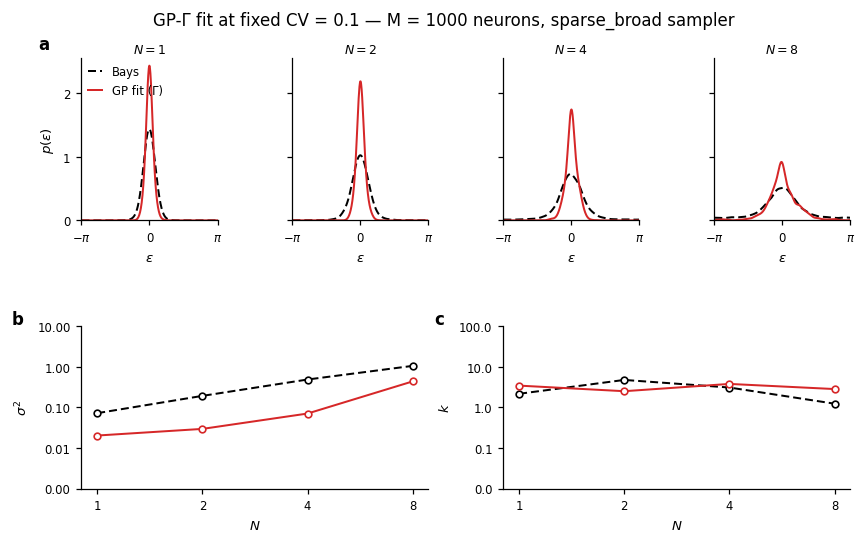

Plotting per-CV figure for CV = 0.5


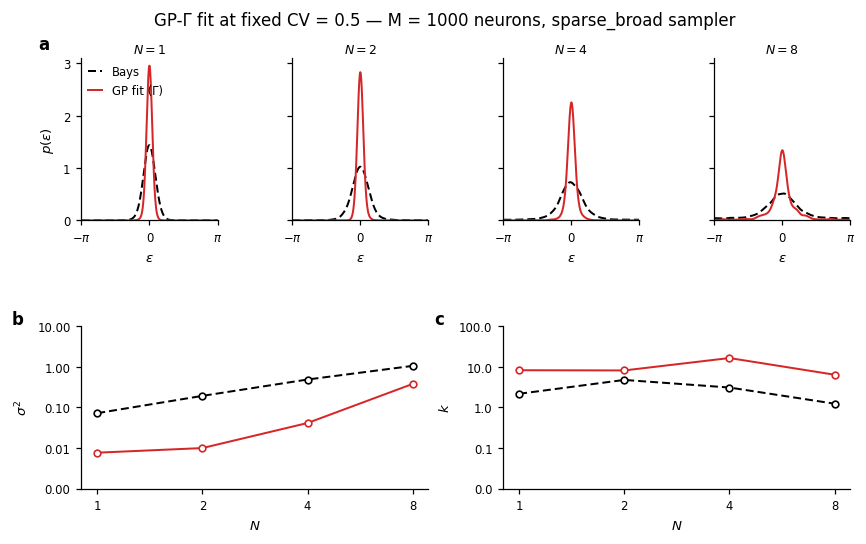

Plotting per-CV figure for CV = 1.0


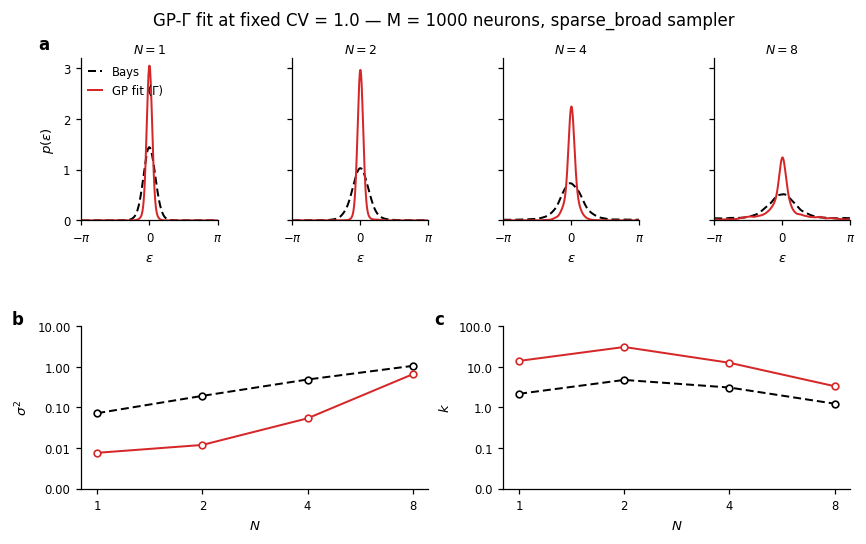

Plotting per-CV figure for CV = 2.0


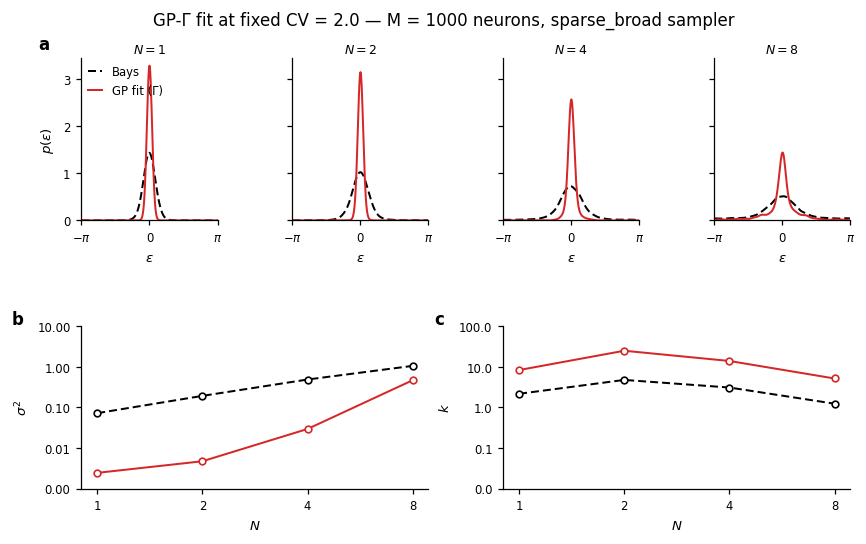

Plotting per-CV figure for CV = 5.0


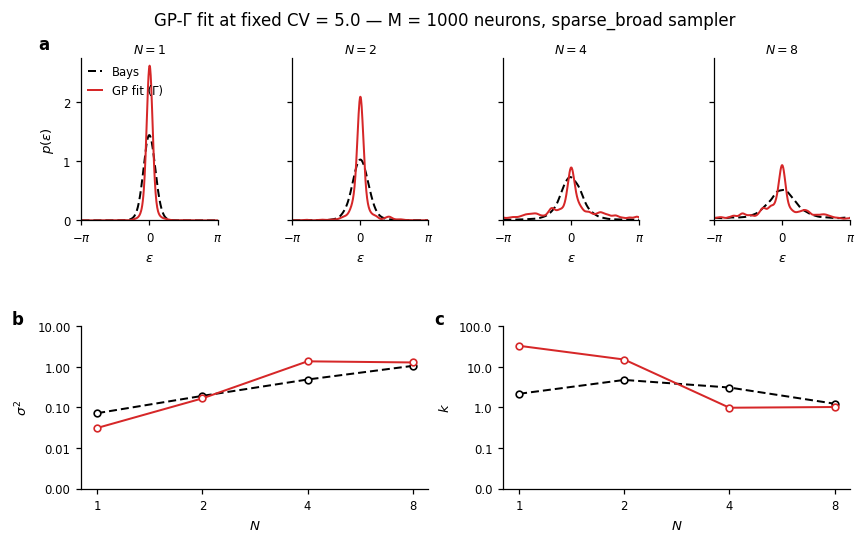

Plotting per-CV figure for CV = 10.0


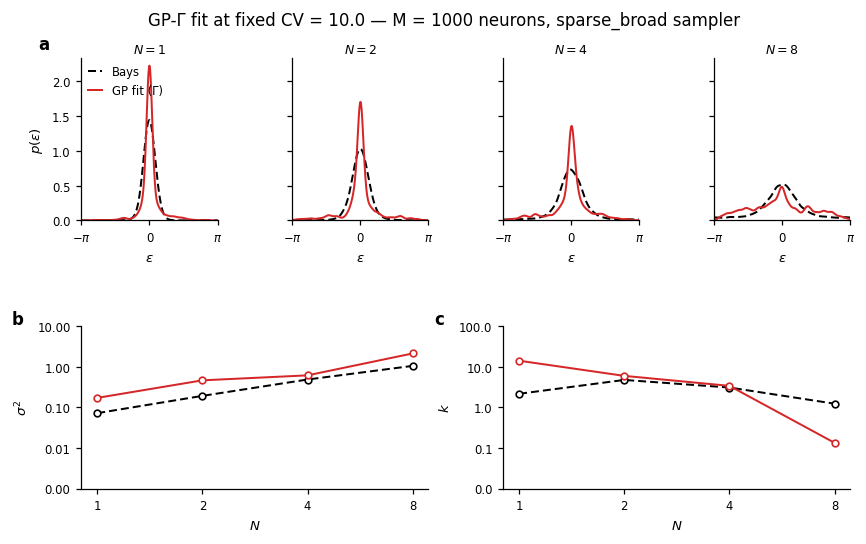

In [29]:
# === Part 3 — Style, helpers, and per-CV detail figures ===
NATURE_STYLE = {
    'font.family':        'sans-serif',
    'font.sans-serif':    ['DejaVu Sans', 'Helvetica', 'Arial'],
    'font.size':          8,
    'axes.labelsize':     8,
    'axes.titlesize':     9,
    'xtick.labelsize':    7,
    'ytick.labelsize':    7,
    'legend.fontsize':    7,
    'axes.linewidth':     0.75,
    'xtick.major.width':  0.75,
    'ytick.major.width':  0.75,
    'xtick.major.size':   3.0,
    'ytick.major.size':   3.0,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'lines.linewidth':    1.2,
    'savefig.dpi':        300,
    'figure.dpi':         120,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
}

GP_COLOR       = '#D62728'
BAYS_COLOR     = '#000000'
BAYS_LINESTYLE = (0, (4, 2))   # dashed Bays reference
KDE_YTICKS     = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]


def _style_axes(ax):
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(0.75)
    ax.tick_params(width=0.75, length=3.0, direction='out')


def _setsize_log_axis(ax, set_sizes):
    """Log x-axis showing only the set sizes actually sampled, no minor ticks."""
    ax.set_xscale('log')
    ax.set_xticks(set_sizes)
    ax.set_xticklabels([str(N) for N in set_sizes])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.get_xaxis().set_major_formatter(ScalarFormatter())


def _auto_log_y(ax, lo, hi):
    """Decade major ticks across [lo, hi] from the sweep-wide data extent."""
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(NullLocator())
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    ax.yaxis.set_major_formatter(fmt)


def _pick_kde_yticks(ymax):
    if ymax <= KDE_YTICKS[-1]:
        return [t for t in KDE_YTICKS if t <= ymax]
    locator = MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    ticks = locator.tick_values(0, ymax)
    return [float(t) for t in ticks if 0 <= t <= ymax]


def plot_cv_fit(cv, result):
    fitted_errors = result['fitted_errors']

    with mpl.rc_context(NATURE_STYLE):
        fig = plt.figure(figsize=(7.2, 4.6))
        gs = gridspec.GridSpec(
            2, len(SET_SIZES),
            hspace=0.65, wspace=0.55,
            left=0.08, right=0.97, bottom=0.12, top=0.90,
        )

        fig.suptitle(f'GP-\u0393 fit at fixed CV = {cv} — {_meta_title()}',
                     fontsize=10, y=0.985)

        kdes_data = {N: vonmises_kde(bays_errs[N],     theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}
        kdes_fit  = {N: vonmises_kde(fitted_errors[N], theta_smooth_fit, kappa=KAPPA_BAYS_AC)
                     for N in SET_SIZES}

        peak = max(max(k.max() for k in kdes_data.values()),
                   max(k.max() for k in kdes_fit.values()))
        kde_ymax = peak * 1.05
        kde_yticks = _pick_kde_yticks(kde_ymax)

        # ---- Row 1: KDE overlays ----
        for i, N in enumerate(SET_SIZES):
            ax = fig.add_subplot(gs[0, i])
            ax.plot(theta_smooth_fit, kdes_data[N], color=BAYS_COLOR, lw=1.2,
                    linestyle=BAYS_LINESTYLE, label='Bays' if i == 0 else None)
            ax.plot(theta_smooth_fit, kdes_fit[N], color=GP_COLOR, lw=1.2,
                    label='GP fit (\u0393)' if i == 0 else None)
            ax.set_xlim(-np.pi, np.pi)
            ax.set_xticks([-np.pi, 0, np.pi])
            ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
            ax.set_yticks(kde_yticks)
            ax.set_ylim(0, kde_ymax)
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())
            ax.set_xlabel(r'$\varepsilon$')
            ax.set_title(f'$N={N}$', fontsize=7.5, pad=3)

            if i == 0:
                ax.set_ylabel(r'$p(\varepsilon)$')
                ax.legend(loc='upper left', frameon=False, handlelength=1.2,
                          borderaxespad=0.2)
                ax.text(-0.32, 1.14, 'a', transform=ax.transAxes,
                        fontsize=10, fontweight='bold', va='top')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            _style_axes(ax)

        # ---- Row 2: variance and kurtosis (shared sweep-wide log range) ----
        var_fit  = np.array([circular_moments(fitted_errors[N])['variance']  for N in SET_SIZES])
        kurt_fit = np.array([circular_moments(fitted_errors[N])['kurtosis']  for N in SET_SIZES])

        ax_var = fig.add_subplot(gs[1, :2])
        ax_var.plot(SET_SIZES, var_bays_arr, marker='o', color=BAYS_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_var.plot(SET_SIZES, var_fit, marker='o', color=GP_COLOR,
                    lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_var.set_yscale('log')
        _setsize_log_axis(ax_var, SET_SIZES)
        _auto_log_y(ax_var, VAR_LO, VAR_HI)
        ax_var.set_xlabel(r'$N$')
        ax_var.set_ylabel(r'$\sigma^2$')
        ax_var.text(-0.20, 1.10, 'b', transform=ax_var.transAxes,
                    fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_var)

        ax_kurt = fig.add_subplot(gs[1, 2:])
        ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o', color=BAYS_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0, linestyle=BAYS_LINESTYLE)
        ax_kurt.plot(SET_SIZES, kurt_fit, marker='o', color=GP_COLOR,
                     lw=1.2, ms=4, mfc='white', mew=1.0)
        ax_kurt.set_yscale('log')
        _setsize_log_axis(ax_kurt, SET_SIZES)
        _auto_log_y(ax_kurt, KURT_LO, KURT_HI)
        ax_kurt.set_xlabel(r'$N$')
        ax_kurt.set_ylabel(r'$k$')
        ax_kurt.text(-0.20, 1.10, 'c', transform=ax_kurt.transAxes,
                     fontsize=10, fontweight='bold', va='top')
        _style_axes(ax_kurt)

        cv_tag = str(cv).replace('.', 'p')
        stem = f'cv_sweep_{_meta_suffix()}_cv{cv_tag}'
        png_path = os.path.join(SWEEP_OUTPUT_DIR, f'{stem}.png')
        pdf_path = os.path.join(SWEEP_OUTPUT_DIR, f'{stem}.pdf')
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        plt.show()


for cv in CV_VALUES:
    print(f'Plotting per-CV figure for CV = {cv}')
    plot_cv_fit(cv, sweep_results[cv])

In [30]:
for name in ['_meta_title', '_meta_suffix', 'theta_smooth_fit',
             'VAR_LO', 'KURT_LO', 'NATURE_STYLE', 'sweep_results', 'CV_VALUES']:
    print(f'{name:20s} {"OK" if name in globals() else "MISSING"}')

_meta_title          OK
_meta_suffix         OK
theta_smooth_fit     OK
VAR_LO               OK
KURT_LO              OK
NATURE_STYLE         OK
sweep_results        OK
CV_VALUES            OK


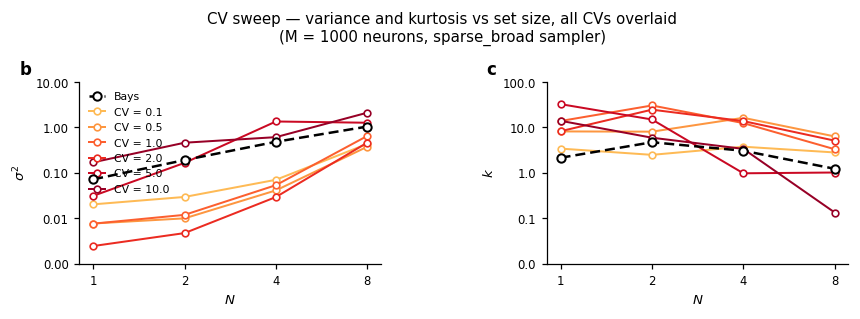


All figures saved to: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_2_20260622_140448


In [31]:
# === Part 4 — Summary figure: variance & kurtosis vs N, all CVs overlaid ===
norm = Normalize(vmin=0, vmax=len(CV_VALUES) - 1)
cmap = plt.get_cmap('YlOrRd')
cv_colors = [cmap(0.35 + 0.6 * norm(i)) for i in range(len(CV_VALUES))]

with mpl.rc_context(NATURE_STYLE):
    fig = plt.figure(figsize=(7.2, 2.8))
    gs = gridspec.GridSpec(
        1, 2,
        wspace=0.55,
        left=0.08, right=0.97, bottom=0.24, top=0.78,
    )

    fig.suptitle(
        f'CV sweep — variance and kurtosis vs set size, all CVs overlaid\n'
        f'({_meta_title()})',
        fontsize=9, y=0.99,
    )

    # --- Variance panel: holds the single legend ---
    ax_var = fig.add_subplot(gs[0, 0])
    ax_var.plot(SET_SIZES, var_bays_arr, marker='o',
                color=BAYS_COLOR, lw=1.5, ms=5, mfc='white', mew=1.2,
                linestyle=BAYS_LINESTYLE, label='Bays', zorder=10)
    for i, cv in enumerate(CV_VALUES):
        v = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['variance']
                      for N in SET_SIZES])
        ax_var.plot(SET_SIZES, v, marker='o',
                    color=cv_colors[i], lw=1.2, ms=4, mfc='white', mew=1.0,
                    label=f'CV = {cv}')
    ax_var.set_yscale('log')
    _setsize_log_axis(ax_var, SET_SIZES)
    _auto_log_y(ax_var, VAR_LO, VAR_HI)
    ax_var.set_xlabel(r'$N$')
    ax_var.set_ylabel(r'$\sigma^2$')
    ax_var.legend(loc='upper left', frameon=False, handlelength=1.5,
                  fontsize=6.5, ncol=1)
    ax_var.text(-0.20, 1.12, 'b', transform=ax_var.transAxes,
                fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_var)

    # --- Kurtosis panel: no legend (shared with variance panel) ---
    ax_kurt = fig.add_subplot(gs[0, 1])
    ax_kurt.plot(SET_SIZES, kurt_bays_arr, marker='o',
                 color=BAYS_COLOR, lw=1.5, ms=5, mfc='white', mew=1.2,
                 linestyle=BAYS_LINESTYLE, zorder=10)
    for i, cv in enumerate(CV_VALUES):
        k = np.array([circular_moments(sweep_results[cv]['fitted_errors'][N])['kurtosis']
                      for N in SET_SIZES])
        ax_kurt.plot(SET_SIZES, k, marker='o',
                     color=cv_colors[i], lw=1.2, ms=4, mfc='white', mew=1.0)
    ax_kurt.set_yscale('log')
    _setsize_log_axis(ax_kurt, SET_SIZES)
    _auto_log_y(ax_kurt, KURT_LO, KURT_HI)
    ax_kurt.set_xlabel(r'$N$')
    ax_kurt.set_ylabel(r'$k$')
    ax_kurt.text(-0.20, 1.12, 'c', transform=ax_kurt.transAxes,
                 fontsize=10, fontweight='bold', va='top')
    _style_axes(ax_kurt)

    summary_stem = f'cv_sweep_{_meta_suffix()}_variance_kurtosis'
    summary_png = os.path.join(SWEEP_OUTPUT_DIR, f'{summary_stem}.png')
    summary_pdf = os.path.join(SWEEP_OUTPUT_DIR, f'{summary_stem}.pdf')
    fig.savefig(summary_png, dpi=300, bbox_inches='tight')
    fig.savefig(summary_pdf, bbox_inches='tight')
    plt.show()

print(f'\nAll figures saved to: {SWEEP_OUTPUT_DIR}')

## Other Experiments

Downstream diagnostics (GP sweeps, the 6-panel GP figure, GP-vs-Bays overlay, M-scaling). The global `M` / `GP_SAMPLER` flags were removed, so these now **inherit `M_FIT` / `DISTRIBUTION_FIT` from the GP-to-Bays Fit** by default — run that control cell first. Each section has optional `M_LOC` / `GP_SAMPLER_LOC` overrides, and writes into the same shared `OUTPUT_DIR`.

### GP Sweep — Group Mean


In [32]:
# === Per-section overrides (None = use global) ===
# Defaults inherit from the GP-to-Bays Fit (run that control cell first).
M_LOC                       = None     # override: 100 / 1000 / 10000
GP_SAMPLER_LOC              = None     # override: folded_normal/gamma/sparse_broad
LENGTHSCALE_VARIABILITY     = 0.3      # GP-side spread of lengthscales
GAIN_VARIABILITY            = 0.0      # GP-side amplitude variability
N_TRIALS                    = 5000     # trials per set size, per seed

_M_local       = M_FIT if M_LOC is None else M_LOC
_sampler_local = DISTRIBUTION_FIT if GP_SAMPLER_LOC is None else GP_SAMPLER_LOC
_gamma_local   = GAMMA_TOTAL_BAYS / _M_local

print(f'GP group sweep: M={_M_local}, sampler={_sampler_local!r}, '
      f'lengthscale_var={LENGTHSCALE_VARIABILITY}, '
      f'gain_var={GAIN_VARIABILITY}, trials={N_TRIALS}, seeds={N_SEEDS}')

max_locs = max(SET_SIZES)
t0 = time.time()
all_seeds = []

for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(
        _M_local, N_THETA, LAMBDA_BASE, max_locs, cseed,
        lengthscale_variability=LENGTHSCALE_VARIABILITY,
        gain_variability=GAIN_VARIABILITY,
        sampler=_sampler_local,
    )
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            _gamma_local, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f} '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds.append(seed_data)

# Aggregate across seeds
summary = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds]
    ks = [sd[N]['kurtosis'] for sd in all_seeds]
    emps = np.array([sd[N]['deviation']['empirical'] for sd in all_seeds])
    devs = np.array([sd[N]['deviation']['deviation'] for sd in all_seeds])
    summary[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'emp_mean':  np.mean(emps, axis=0),
        'emp_se':    np.std(emps, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(emps[0]),
        'dev_mean':  np.mean(devs, axis=0),
        'dev_se':    np.std(devs, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(devs[0]),
    }
bins = all_seeds[0][SET_SIZES[0]]['deviation']['bin_centers']
print(f'Done in {time.time()-t0:.1f}s')


GP group sweep: M=1000, sampler='sparse_broad', lengthscale_var=0.3, gain_var=0.0, trials=5000, seeds=5
  seed=0 N=1: var=0.1995 kurt=16.302
  seed=0 N=2: var=0.2318 kurt=14.004
  seed=0 N=4: var=0.3017 kurt=10.943
  seed=0 N=8: var=0.8144 kurt=3.256
  seed=1 N=1: var=0.1872 kurt=16.461
  seed=1 N=2: var=0.2049 kurt=15.286
  seed=1 N=4: var=0.2800 kurt=11.772
  seed=1 N=8: var=0.6361 kurt=4.543
  seed=2 N=1: var=0.2138 kurt=15.996
  seed=2 N=2: var=0.2149 kurt=14.303
  seed=2 N=4: var=0.2751 kurt=10.899
  seed=2 N=8: var=0.5963 kurt=4.752
  seed=3 N=1: var=0.2047 kurt=16.104
  seed=3 N=2: var=0.1972 kurt=15.344
  seed=3 N=4: var=0.2923 kurt=11.275
  seed=3 N=8: var=0.7135 kurt=3.617
  seed=4 N=1: var=0.1979 kurt=16.436
  seed=4 N=2: var=0.1983 kurt=16.046
  seed=4 N=4: var=0.2913 kurt=11.014
  seed=4 N=8: var=0.5988 kurt=4.409
Done in 66.4s


### GP Sweep — Single Subject


In [33]:
# === Per-section overrides ===
# Defaults inherit from the GP-to-Bays Fit (run that control cell first).
M_LOC                       = None     # override: 100 / 1000 / 10000
GP_SAMPLER_LOC              = None     # override: folded_normal/gamma/sparse_broad
OMEGA_SINGLE                = 0.65
GAMMA_SINGLE_TOTAL          = 113.0

_M_local       = M_FIT if M_LOC is None else M_LOC
_sampler_local = DISTRIBUTION_FIT if GP_SAMPLER_LOC is None else GP_SAMPLER_LOC

LAMBDA_BASE_SINGLE = np.sqrt(OMEGA_SINGLE)
GAMMA_SINGLE       = GAMMA_SINGLE_TOTAL / _M_local

print(f'GP single-subject sweep: omega={OMEGA_SINGLE}, '
      f'gamma_total={GAMMA_SINGLE_TOTAL} Hz, M={_M_local}, sampler={_sampler_local!r}')

max_locs = max(SET_SIZES)
t0 = time.time()
all_seeds_single = []
for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(
        _M_local, N_THETA, LAMBDA_BASE_SINGLE, max_locs, cseed,
        lengthscale_variability=LENGTHSCALE_VARIABILITY,
        gain_variability=GAIN_VARIABILITY,
        sampler=_sampler_local,
    )
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA_SINGLE, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_single.append(seed_data)

summary_single = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds_single]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_single]
    summary_single[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
    }
print(f'Done in {time.time()-t0:.1f}s')


GP single-subject sweep: omega=0.65, gamma_total=113.0 Hz, M=1000, sampler='sparse_broad'
Done in 73.8s


### Bays Summary (from Cache)


In [34]:
# === Reconstruct seed-stratified summary from the Bays cache ===
# The cache stores 10,000 trials per set size as a single array. To
# mimic the multi-seed sweep structure that the overlay plot expects,
# we partition the cached errors into N_SEEDS equal chunks. The
# resulting summary_bays values match the cached statistics in
# expectation but have honest seed-level standard errors.

all_seeds_bays = []
_n_trials_per_seed = len(bays_cached_errors[SET_SIZES[0]]) // N_SEEDS
print(f'Partitioning Bays cache into {N_SEEDS} pseudo-seeds of '
      f'{_n_trials_per_seed} trials each')

for s in range(N_SEEDS):
    seed_data = {}
    lo, hi = s * _n_trials_per_seed, (s + 1) * _n_trials_per_seed
    for N in SET_SIZES:
        errors = bays_cached_errors[N][lo:hi]
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors':    errors,
            'variance':  moments['variance'],
            'kurtosis':  moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
    all_seeds_bays.append(seed_data)

summary_bays = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds_bays]
    ks = [sd[N]['kurtosis'] for sd in all_seeds_bays]
    emps = np.array([sd[N]['deviation']['empirical']  for sd in all_seeds_bays])
    devs = np.array([sd[N]['deviation']['deviation']  for sd in all_seeds_bays])
    n_eff = N_SEEDS
    summary_bays[N] = {
        'var_mean':  np.mean(vs),
        'var_se':    np.std(vs, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se':   np.std(ks, ddof=1) / np.sqrt(n_eff) if n_eff > 1 else 0,
        'emp_mean':  np.mean(emps, axis=0),
        'emp_se':    (np.std(emps, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(emps[0])),
        'dev_mean':  np.mean(devs, axis=0),
        'dev_se':    (np.std(devs, axis=0, ddof=1) / np.sqrt(n_eff)
                      if n_eff > 1 else np.zeros_like(devs[0])),
    }
bins_bays = all_seeds_bays[0][SET_SIZES[0]]['deviation']['bin_centers']

# Also build a single-subject Bays summary by re-using the cache —
# we don't have a separate "single-subject" cache, so we use the same
# group-mean cache here. If you need a true single-subject cache at
# omega=0.65, build a separate cache file and load it explicitly.
all_seeds_bays_single = all_seeds_bays   # alias — same parameters
summary_bays_single = summary_bays

print('Built summary_bays and summary_bays_single from cache')


Partitioning Bays cache into 5 pseudo-seeds of 2000 trials each
Built summary_bays and summary_bays_single from cache


### Figure 2 — GP Variant (panels a–f)


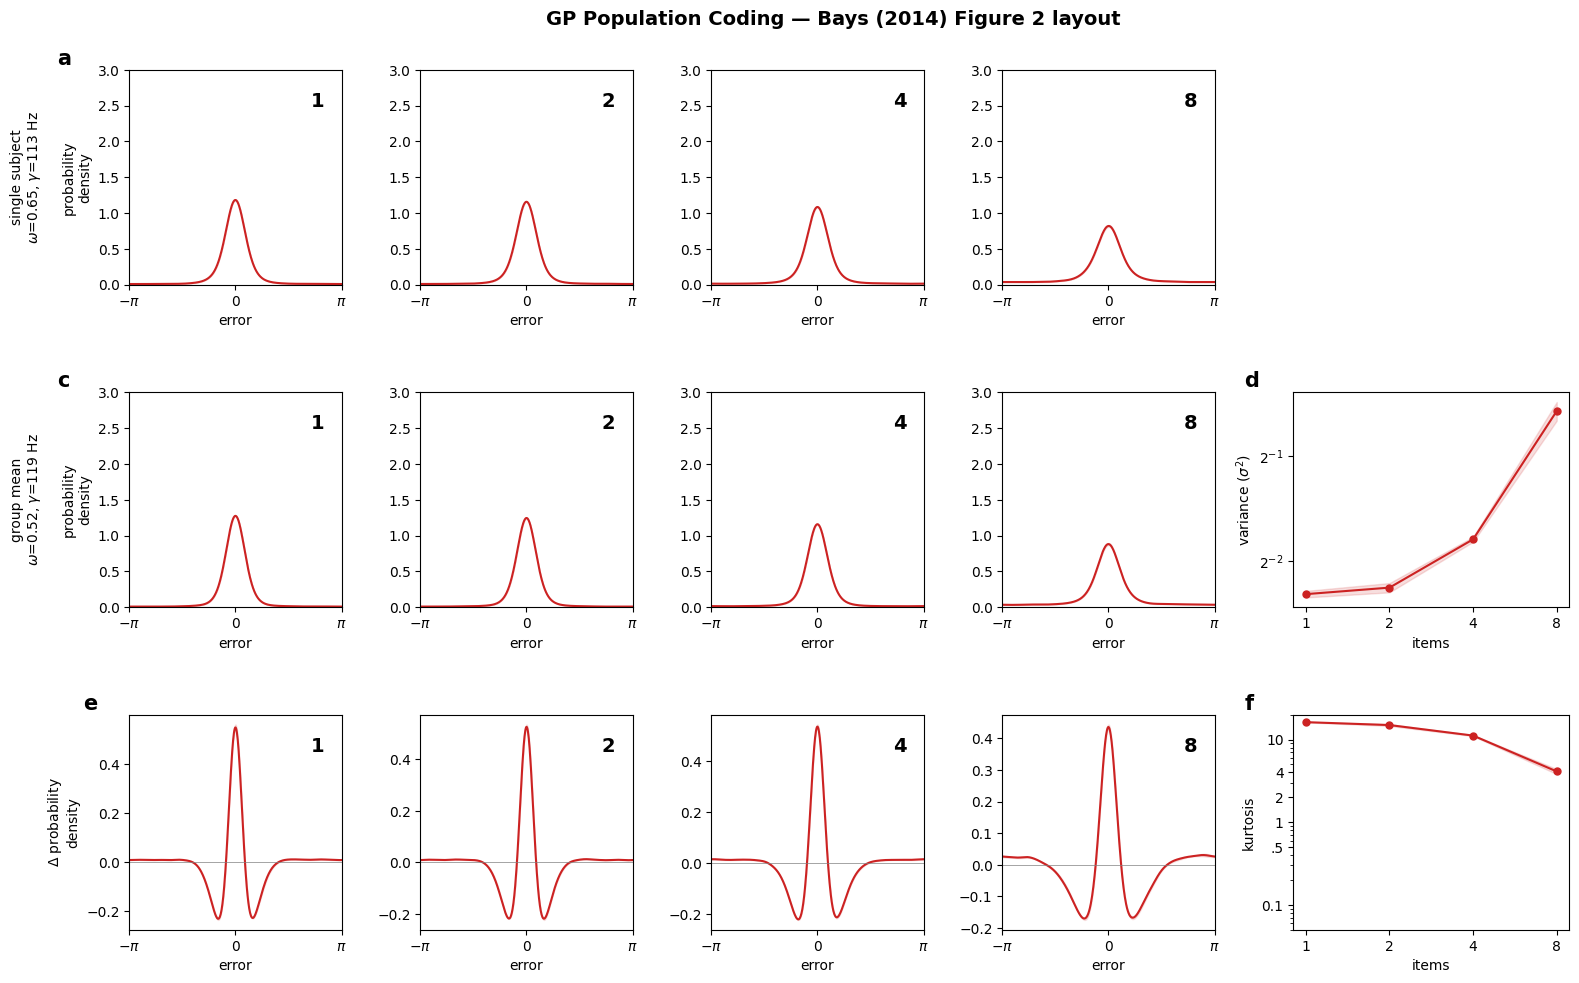

In [35]:
# === GP figure: two-row layout matching Bays (2014) Figure 2 ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f

RED = '#CC2222'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)

# ---- Row 1: SINGLE-SUBJECT distributions (panel a equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[0, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds_single
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'single subject\n$\\omega$={OMEGA_SINGLE}, '
                      f'$\\gamma$={GAMMA_SINGLE_TOTAL:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{a}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 1, last column: leave blank (panel b in paper is parameter scatter, not a curve)
ax_blank = fig.add_subplot(gs[0, len(SET_SIZES)])
ax_blank.axis('off')

# ---- Row 2: GROUP-MEAN distributions (panel c equivalent) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    seed_kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        for sd in all_seeds
    ])
    kde_mean = seed_kdes.mean(axis=0)
    kde_se = (seed_kdes.std(axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_TOTAL_BAYS:.0f} Hz\n\nprobability\ndensity')
        ax.text(-0.34, 1.10, r'$\mathbf{c}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Row 2, last column: panel d (variance vs items at group-mean params)
ax_d = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
vm  = np.array([summary[N]['var_mean'] for N in SET_SIZES])
vse = np.array([summary[N]['var_se']   for N in SET_SIZES])
ax_d.plot(ns, vm, 'o-', color=RED, lw=1.5, ms=5)
ax_d.fill_between(ns, vm - vse, vm + vse, color=RED, alpha=0.15)
ax_d.set_xscale('log', base=2); ax_d.set_yscale('log', base=2)
ax_d.set_xticks(SET_SIZES); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items'); ax_d.set_ylabel(r'variance ($\sigma^2$)')
ax_d.text(-0.18, 1.10, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---- Row 3: deviation from normal (e) + kurtosis (f), group-mean only ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    all_err = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_e = np.abs(np.mean(np.exp(1j * all_err)))
    kappa_e = _estimate_von_mises_kappa(max(rho1_e, 1e-6))
    vm_ref = vonmises.pdf(theta_smooth, kappa_e)
    emp_kde = vonmises_kde(all_err, theta_smooth, kappa=KAPPA_PANEL_E)
    dev_smooth = emp_kde - vm_ref
    ax.plot(theta_smooth, dev_smooth, color=RED, lw=1.5)
    seed_devs = []
    for sd in all_seeds:
        e_s = sd[N]['errors']
        rho1_s = np.abs(np.mean(np.exp(1j * e_s)))
        kappa_s = _estimate_von_mises_kappa(max(rho1_s, 1e-6))
        vm_s = vonmises.pdf(theta_smooth, kappa_s)
        emp_s = vonmises_kde(e_s, theta_smooth, kappa=KAPPA_PANEL_E)
        seed_devs.append(emp_s - vm_s)
    seed_devs = np.array(seed_devs)
    if N_SEEDS > 1:
        dev_se = np.std(seed_devs, axis=0, ddof=1) / np.sqrt(N_SEEDS)
    else:
        dev_se = np.zeros_like(dev_smooth)
    ax.fill_between(theta_smooth, dev_smooth - dev_se, dev_smooth + dev_se,
                    color=RED, alpha=0.12)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability' + '\ndensity')
        ax.text(-0.22, 1.10, r'$\mathbf{e}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
km  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
kse = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
ax_f.plot(ns, km, 'o-', color=RED, lw=1.5, ms=5)
ax_f.fill_between(ns, km - kse, km + kse, color=RED, alpha=0.15)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')
ax_f.text(-0.18, 1.10, r'$\mathbf{f}$', transform=ax_f.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding — Bays (2014) Figure 2 layout',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'bays_fig2_gp.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'bays_fig2_gp.pdf', bbox_inches='tight')
plt.show()


### GP vs Bays — Direct Overlay


In [36]:
# === Overlay: GP variant (red) vs Bays parametric (black) ===
# Row 1: single-subject params (omega=0.65, gamma=113 Hz) — distributions only
# Row 2: group-mean params     (omega=0.52, gamma=119 Hz) — distributions + d/e/f
# Row 3: deviation (e) + kurtosis (f), at group-mean
#
# Within each row, BOTH curves use identical (omega, gamma).  The only thing
# that differs is the encoder (Bays parametric vs GP variant).
#
# Y-axes are SHARED across all 8 distribution panels (rows 1+2) so visual
# heights are directly comparable.  Row 3 deviation panels are also shared.

_required = ['summary', 'summary_bays', 'all_seeds_single', 'all_seeds_bays_single']
_missing = [n for n in _required if n not in globals()]
assert not _missing, (
    f"Missing variables: {_missing}. "
    "Run all four sweeps first (GP group, GP single, Bays group, Bays single)."
)

theta_smooth_ov = np.linspace(-np.pi, np.pi, 500)
GP_COLOR   = '#CC2222'
BAYS_COLOR = 'black'

def _kde_mean_se(seeds_data, N, kappa):
    kdes = np.array([
        vonmises_kde(sd[N]['errors'], theta_smooth_ov, kappa=kappa)
        for sd in seeds_data
    ])
    mean = kdes.mean(axis=0)
    se = (kdes.std(axis=0, ddof=1) / np.sqrt(len(kdes))
          if len(kdes) > 1 else np.zeros_like(mean))
    return mean, se



# ---- Pre-compute all curves so we can determine shared y-limits ----
# Distribution panels (rows 1 & 2)
dist_curves = {}    # (row, set_size) -> dict with mean/se for gp & bays
dist_max = 0.0
for row, (gp_seeds, bays_seeds) in enumerate([
    (all_seeds_single, all_seeds_bays_single),
    (all_seeds,        all_seeds_bays),
]):
    for N in SET_SIZES:
        gp_mean,   gp_se   = _kde_mean_se(gp_seeds,   N, KAPPA_PANELS_AC)
        bays_mean, bays_se = _kde_mean_se(bays_seeds, N, KAPPA_BAYS_AC)
        dist_curves[(row, N)] = dict(
            gp_mean=gp_mean, gp_se=gp_se,
            bays_mean=bays_mean, bays_se=bays_se,
        )
        dist_max = max(dist_max, (gp_mean + gp_se).max(), (bays_mean + bays_se).max())

dist_ylim = (0.0, dist_max * 1.10)
print(f'Shared distribution y-limit: {dist_ylim}')

# Deviation panels (row 3)
dev_curves = {}     # set_size -> dict with gp & bays deviation arrays
dev_min, dev_max = 0.0, 0.0
for N in SET_SIZES:
    all_err_gp = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_gp = np.abs(np.mean(np.exp(1j * all_err_gp)))
    kappa_gp = _estimate_von_mises_kappa(max(rho1_gp, 1e-6))
    vm_gp = vonmises.pdf(theta_smooth_ov, kappa_gp)
    emp_gp = vonmises_kde(all_err_gp, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_gp = emp_gp - vm_gp

    all_err_b = np.concatenate([sd[N]['errors'] for sd in all_seeds_bays])
    rho1_b = np.abs(np.mean(np.exp(1j * all_err_b)))
    kappa_b = _estimate_von_mises_kappa(max(rho1_b, 1e-6))
    vm_b = vonmises.pdf(theta_smooth_ov, kappa_b)
    emp_b = vonmises_kde(all_err_b, theta_smooth_ov, kappa=KAPPA_PANEL_E)
    dev_b = emp_b - vm_b

    dev_curves[N] = dict(gp=dev_gp, bays=dev_b)
    dev_min = min(dev_min, dev_gp.min(), dev_b.min())
    dev_max = max(dev_max, dev_gp.max(), dev_b.max())

# Symmetric y-limit around zero, with 10% padding
dev_abs = max(abs(dev_min), abs(dev_max))
dev_ylim = (-dev_abs * 1.10, dev_abs * 1.10)
print(f'Shared deviation y-limit: {dev_ylim}')

# ---- Now plot ----
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(
    3, len(SET_SIZES) + 1,
    width_ratios=[1] * len(SET_SIZES) + [1.3],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.96, bottom=0.06, top=0.92,
)



# ---- Row 2: GROUP-MEAN (omega=0.52, gamma=119 Hz) ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    c = dist_curves[(1, N)]
    ax.fill_between(theta_smooth_ov, c['bays_mean'] - c['bays_se'],
                    c['bays_mean'] + c['bays_se'],
                    color=BAYS_COLOR, alpha=0.15, lw=0)
    ax.plot(theta_smooth_ov, c['bays_mean'], color=BAYS_COLOR, lw=1.5)
    ax.fill_between(theta_smooth_ov, c['gp_mean'] - c['gp_se'],
                    c['gp_mean'] + c['gp_se'],
                    color=GP_COLOR, alpha=0.18, lw=0)
    ax.plot(theta_smooth_ov, c['gp_mean'], color=GP_COLOR, lw=1.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dist_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(f'group mean\n$\\omega$={OMEGA_BAYS}, '
                      f'$\\gamma$={GAMMA_BAYS:.0f} Hz\n\nprobability density')

# Panel d: variance overlay (group mean)
ax_v = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
gv  = np.array([summary[N]['var_mean']      for N in SET_SIZES])
gvs = np.array([summary[N]['var_se']        for N in SET_SIZES])
bv  = np.array([summary_bays[N]['var_mean'] for N in SET_SIZES])
bvs = np.array([summary_bays[N]['var_se']   for N in SET_SIZES])
ax_v.errorbar(ns, gv, yerr=gvs, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5, label='GP')
ax_v.errorbar(ns, bv, yerr=bvs, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5, label='Bays')
ax_v.set_xscale('log', base=2); ax_v.set_yscale('log', base=2)
ax_v.set_xticks(SET_SIZES); ax_v.set_xticklabels([str(n) for n in SET_SIZES])
ax_v.set_xlabel('items'); ax_v.set_ylabel(r'variance ($\sigma^2$)')
ax_v.legend(fontsize=8, frameon=False)

# ---- Row 3: deviation (e) + kurtosis (f), overlay at group-mean ----
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    d = dev_curves[N]
    ax.plot(theta_smooth_ov, d['bays'], color=BAYS_COLOR, lw=1.5)
    ax.plot(theta_smooth_ov, d['gp'],   color=GP_COLOR,   lw=1.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(*dev_ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.92, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability density')

# Panel f: kurtosis overlay (group mean)
ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
gk  = np.array([summary[N]['kurt_mean'] for N in SET_SIZES])
gks = np.array([summary[N]['kurt_se']   for N in SET_SIZES])
bk  = np.array([summary_bays[N]['kurt_mean'] for N in SET_SIZES])
bks = np.array([summary_bays[N]['kurt_se']   for N in SET_SIZES])
ax_f.errorbar(ns, gk, yerr=gks, fmt='o-', color=GP_COLOR,   lw=1.5, ms=5)
ax_f.errorbar(ns, bk, yerr=bks, fmt='s-', color=BAYS_COLOR, lw=1.5, ms=5)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')

fig.suptitle('Overlay: GP variant (red) vs Bays parametric (black) — '
             'matched parameters per row',
             fontsize=14, fontweight='bold')
plt.savefig(OUTPUT_DIR / 'bays_fig2_overlay.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'bays_fig2_overlay.pdf', bbox_inches='tight')
plt.show()


Shared distribution y-limit: (0.0, 1.5919434551230416)
Shared deviation y-limit: (-0.6028061863107363, 0.6028061863107363)


NameError: name 'GAMMA_BAYS' is not defined

### Diagnostics — GP-Γ vs Bays


In [ ]:
# === Diagnostic 1: Kurtosis (and variance) arrays, GP-Gamma vs Bays ===
# Prints raw numbers behind the bottom-right panel of the GP-Gamma fit plot.
# Mirrors how Bays Figure 2f is reported but as a side-by-side table you can
# read directly without squinting at the plot.

print('=' * 72)
print('Per-set-size moments: cached Bays vs fitted GP-Gamma')
print('=' * 72)

bays_var  = np.array([circular_moments(bays_cached_errors[N])['variance']
                      for N in SET_SIZES])
bays_kurt = np.array([circular_moments(bays_cached_errors[N])['kurtosis']
                      for N in SET_SIZES])
gp_var    = np.array([circular_moments(fitted_errors_gamma[N])['variance']
                      for N in SET_SIZES])
gp_kurt   = np.array([circular_moments(fitted_errors_gamma[N])['kurtosis']
                      for N in SET_SIZES])

print(f'\nSet sizes:        {list(SET_SIZES)}')
print(f'\nVariance (Bays):  {np.array2string(bays_var,  precision=4)}')
print(f'Variance (GP-Γ):  {np.array2string(gp_var,    precision=4)}')
print(f'\nKurtosis (Bays):  {np.array2string(bays_kurt, precision=3)}')
print(f'Kurtosis (GP-Γ):  {np.array2string(gp_kurt,   precision=3)}')

# Side-by-side table
print(f'\n{"N":>4} | {"var_Bays":>10} {"var_GP":>10} {"Δvar":>10} | '
      f'{"k_Bays":>10} {"k_GP":>10} {"Δk":>10}')
print('-' * 72)
for i, N in enumerate(SET_SIZES):
    print(f'{N:>4} | {bays_var[i]:>10.4f} {gp_var[i]:>10.4f} '
          f'{gp_var[i]-bays_var[i]:>+10.4f} | '
          f'{bays_kurt[i]:>10.3f} {gp_kurt[i]:>10.3f} '
          f'{gp_kurt[i]-bays_kurt[i]:>+10.3f}')

# Expose as named arrays so later cells / interactive use don't have to recompute
bays_kurt_array = bays_kurt
gp_kurt_array   = gp_kurt
print('\nExposed: bays_kurt_array, gp_kurt_array '
      f'(shape {bays_kurt_array.shape} each)')


# === Quantization diagnostic: unique error counts and exact-zero hits ===
# Before the continuous-θ fix in cell 11 (`run_multiloc_trials`) and the
# matching fix in `core.population.Population.run_trials`, GP-Γ drew true
# orientations from the same n_theta-point grid the decoder evaluates on.
# That caused exact "θ_hat == θ_true" hits and a delta-at-zero in the
# error distribution, which inflated kurtosis at low set sizes.
#
# After the fix, both pipelines should look the same here:
#   * uniq_GP   ≈ trial count (every error distinct, off-grid)
#   * zero_GP   ≈ 0          (no exact-zero spike)
#   * min|e|_GP ≈ tiny       (NOT equal to 2π/n_theta any more)
#
# Bays remains the reference: continuous truth, 1000-point decoder grid,
# so it never had the artefact in the first place.

print('\n' + '=' * 72)
print('Quantization check: unique errors and exact-zero hits')
print('=' * 72)
print(f'(Decoder grid spacing 2π/N_THETA = {2*np.pi/N_THETA:.6f} rad)')
print(f'\n{"N":>4} | {"uniq_Bays":>10} {"zero_Bays":>10} {"min|e|_B":>10} | '
      f'{"uniq_GP":>10} {"zero_GP":>10} {"min|e|_GP":>10}')
print('-' * 72)
for N in SET_SIZES:
    e_b = bays_cached_errors[N]
    e_g = fitted_errors_gamma[N]
    uniq_b = len(np.unique(e_b))
    uniq_g = len(np.unique(e_g))
    zero_b = int(np.sum(e_b == 0.0))
    zero_g = int(np.sum(e_g == 0.0))
    min_b  = np.min(np.abs(e_b[e_b != 0])) if (e_b != 0).any() else np.nan
    min_g  = np.min(np.abs(e_g[e_g != 0])) if (e_g != 0).any() else np.nan
    print(f'{N:>4} | {uniq_b:>10d} {zero_b:>10d} {min_b:>10.6f} | '
          f'{uniq_g:>10d} {zero_g:>10d} {min_g:>10.6f}')


In [ ]:
# === Diagnostic 2: Isolate errors per set size, KDE + histogram, fraction-at-zero ===
# For each set size in SET_SIZES we:
#   1. Pull the two error arrays (cached Bays, fitted GP-Gamma)
#   2. Print summary stats incl. circular kurtosis (Fisher) and fraction-at-zero
#   3. Apply von Mises KDE to both arrays
#   4. Plot KDE overlay AND histogram-with-KDE in a 2-column-per-set-size figure
#
# "Fraction-at-zero" is operationalised as the fraction of trials whose error
# falls inside the central bin of width 2*EPS_ZERO around 0. With EPS_ZERO=π/N_BINS
# this is just "fraction of trials in the central histogram bin".

# Pick which set size to inspect interactively. Change this to dig into any
# single condition; the loop below covers all of them regardless.
INSPECT_N = 1
EPS_ZERO  = np.pi / 50   # half-width of "at-zero" bin (= one of 50 bins)
KAPPA_KDE = 80.0         # KDE smoothing — see the dedicated sweep cell below

print('=' * 78)
print(f'Per-set-size diagnostic | KDE κ = {KAPPA_KDE} | '
      f'zero-bin half-width = {EPS_ZERO:.4f} rad')
print('=' * 78)

theta_eval = np.linspace(-np.pi, np.pi, 500)
diagnostic_summary = {}

for N in SET_SIZES:
    e_bays = bays_cached_errors[N]
    e_gp   = fitted_errors_gamma[N]

    m_bays = circular_moments(e_bays)
    m_gp   = circular_moments(e_gp)

    frac_zero_bays = np.mean(np.abs(e_bays) < EPS_ZERO)
    frac_zero_gp   = np.mean(np.abs(e_gp)   < EPS_ZERO)

    print(f'\n--- N = {N} ---')
    print(f'  Bays errors:  shape={e_bays.shape}, '
          f'first 8 = {np.array2string(e_bays[:8], precision=3)}')
    print(f'  GP-Γ errors:  shape={e_gp.shape}, '
          f'first 8 = {np.array2string(e_gp[:8],   precision=3)}')
    print(f'  Bays:  circ_var = {m_bays["variance"]:.4f}   '
          f'circ_kurt (Fisher) = {m_bays["kurtosis"]:>7.3f}   '
          f'frac(|err|<{EPS_ZERO:.3f}) = {frac_zero_bays:.4f}')
    print(f'  GP-Γ:  circ_var = {m_gp["variance"]:.4f}   '
          f'circ_kurt (Fisher) = {m_gp["kurtosis"]:>7.3f}   '
          f'frac(|err|<{EPS_ZERO:.3f}) = {frac_zero_gp:.4f}')

    diagnostic_summary[N] = {
        'bays_errors':    e_bays,
        'gp_errors':      e_gp,
        'bays_kurt':      m_bays['kurtosis'],
        'gp_kurt':        m_gp['kurtosis'],
        'bays_frac_zero': frac_zero_bays,
        'gp_frac_zero':   frac_zero_gp,
    }

# --- Figure: one row per set size, [KDE overlay | histogram + KDE] ---
n_rows = len(SET_SIZES)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.6 * n_rows),
                         squeeze=False)

for r, N in enumerate(SET_SIZES):
    e_bays = bays_cached_errors[N]
    e_gp   = fitted_errors_gamma[N]
    kde_bays = vonmises_kde(e_bays, theta_eval, kappa=KAPPA_KDE)
    kde_gp   = vonmises_kde(e_gp,   theta_eval, kappa=KAPPA_KDE)

    # Column 0: KDE overlay, no histogram (clean view of density shape)
    ax = axes[r, 0]
    ax.plot(theta_eval, kde_bays, color='black',   lw=1.3, label='Bays (cached)')
    ax.plot(theta_eval, kde_gp,   color='#D62728', lw=1.3, label='GP-Γ fit')
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(
        f'N={N}: KDE only  |  '
        f'k_Bays={diagnostic_summary[N]["bays_kurt"]:.2f}, '
        f'k_GP={diagnostic_summary[N]["gp_kurt"]:.2f}',
        fontsize=9)
    if r == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=8)

    # Column 1: histogram + KDE for each model, side by side via alpha
    ax = axes[r, 1]
    bins = np.linspace(-np.pi, np.pi, 51)
    ax.hist(e_bays, bins=bins, density=True, color='black',
            alpha=0.25, label='Bays hist')
    ax.hist(e_gp,   bins=bins, density=True, color='#D62728',
            alpha=0.25, label='GP-Γ hist')
    ax.plot(theta_eval, kde_bays, color='black',   lw=1.3, label='Bays KDE')
    ax.plot(theta_eval, kde_gp,   color='#D62728', lw=1.3, label='GP-Γ KDE')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(
        f'N={N}: hist + KDE  |  '
        f'frac0_Bays={diagnostic_summary[N]["bays_frac_zero"]:.3f}, '
        f'frac0_GP={diagnostic_summary[N]["gp_frac_zero"]:.3f}',
        fontsize=9)
    if r == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=7, ncol=2)

fig.suptitle('Error diagnostics: cached Bays vs fitted GP-Γ '
             '(KDE, histograms, kurtosis, fraction-at-zero)',
             fontsize=11, y=1.00)
fig.tight_layout()
plt.show()

# --- Brief summary table at the end ---
print('\n' + '=' * 78)
print(f'{"N":>4} | {"k_Bays":>9} {"k_GP":>9} | '
      f'{"frac0_Bays":>11} {"frac0_GP":>11}')
print('-' * 78)
for N in SET_SIZES:
    d = diagnostic_summary[N]
    print(f'{N:>4} | {d["bays_kurt"]:>9.3f} {d["gp_kurt"]:>9.3f} | '
          f'{d["bays_frac_zero"]:>11.4f} {d["gp_frac_zero"]:>11.4f}')


In [ ]:
# === Diagnostic 3: KDE smoothing (κ) hyperparameter sweep ===
# The von Mises KDE used everywhere above has a single tunable knob: κ.
#   high κ  →  narrow kernel  →  less smoothing  →  more wiggle, more peakiness
#   low  κ  →  wide kernel    →  more smoothing  →  flatter, less peakiness
#
# Because circular kurtosis is computed from the raw samples (not the KDE),
# the numbers k_Bays and k_GP do NOT change with κ. What changes is the
# VISUAL impression of how sharp / flat the densities are, which matters when
# you're eyeballing whether the GP fit "matches the peak" of Bays.
#
# This cell sweeps κ ∈ {10, 25, 50, 80, 150, 300} and overlays the resulting
# Bays vs GP-Γ KDEs at one chosen set size so you can see what each setting
# does. Change SWEEP_N to inspect a different set size.

SWEEP_N = 1
KAPPA_SWEEP = [10.0, 25.0, 50.0, 80.0, 150.0, 300.0]

e_bays_s = bays_cached_errors[SWEEP_N]
e_gp_s   = fitted_errors_gamma[SWEEP_N]

print(f'KDE κ sweep at N={SWEEP_N}')
print(f'  Bays trials: {len(e_bays_s)},  GP-Γ trials: {len(e_gp_s)}')
print(f'  (Kurtosis is computed from raw samples, so it does not change '
      f'with κ.)\n')

# Show that kurtosis is κ-invariant by listing it once
k_bays_s = circular_kurtosis_bays(e_bays_s)
k_gp_s   = circular_kurtosis_bays(e_gp_s)
print(f'  circ kurt (Bays) = {k_bays_s:.3f}')
print(f'  circ kurt (GP-Γ) = {k_gp_s:.3f}\n')

theta_eval = np.linspace(-np.pi, np.pi, 500)
n_panels = len(KAPPA_SWEEP)
ncols = 3
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows),
                         squeeze=False)

# Per-panel peak heights so you can see how κ inflates the apparent peak
peak_heights = []
for i, kappa in enumerate(KAPPA_SWEEP):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    kde_b = vonmises_kde(e_bays_s, theta_eval, kappa=kappa)
    kde_g = vonmises_kde(e_gp_s,   theta_eval, kappa=kappa)
    peak_heights.append((kappa, kde_b.max(), kde_g.max()))

    ax.plot(theta_eval, kde_b, color='black',   lw=1.3, label='Bays')
    ax.plot(theta_eval, kde_g, color='#D62728', lw=1.3, label='GP-Γ')
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error (rad)')
    ax.set_ylabel('density')
    ax.set_title(f'κ = {kappa:g}   '
                 f'(peak: Bays={kde_b.max():.2f}, GP={kde_g.max():.2f})',
                 fontsize=9)
    if i == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=8)

# Hide unused subplots
for j in range(n_panels, nrows * ncols):
    axes[j // ncols, j % ncols].axis('off')

fig.suptitle(f'KDE smoothing (κ) sweep at N={SWEEP_N}: '
             f'shape changes, kurtosis does not',
             fontsize=11, y=1.00)
fig.tight_layout()
plt.show()

# --- Numerical summary: peak height vs κ ---
print('\nPeak density vs κ (this is purely a smoothing artefact, not data):')
print(f'  {"κ":>8}  {"peak_Bays":>10}  {"peak_GP":>10}  {"ratio_GP/Bays":>14}')
print('  ' + '-' * 50)
for kappa, pb, pg in peak_heights:
    print(f'  {kappa:>8.1f}  {pb:>10.3f}  {pg:>10.3f}  {pg/pb:>14.3f}')

print(
    '\nGuidance for picking κ:\n'
    '  • κ ≈ 25     : matches the GP-figure default (panels a/c) — broad smoothing\n'
    '  • κ ≈ 44     : matches the GP-figure panel-e default — moderate\n'
    '  • κ ≈ 80     : matches the Bays-figure default (KAPPA_BAYS_AC)\n'
    '  • κ ≳ 200    : near-raw histogram view, lots of wiggle at low set sizes\n'
    '  Pick the smallest κ that still resolves the feature you are trying to see.'
)


### Diagnostic — GP Forward at the Bays Truth


In [ ]:
# === GP forward at Bays-truth parameters ===
# If N=1 kurtosis comes in near Bays's reference, the fit is the issue.
# If it stays high, the GP is structurally different from Bays at N=1.

# Uses the GP-to-Bays Fit's M (the global M was removed). The 'gamma'
# variant below is fixed for the near-homogeneous test, independent of
# DISTRIBUTION_FIT.
_M_local = M_FIT
SEED_FIT = globals().get('SEED_FIT', SEED)
N_TRIALS_FIT = globals().get('N_TRIALS_FIT', 1000)
GAIN_VARIABILITY = globals().get('GAIN_VARIABILITY', 0.0)

max_locs = max(SET_SIZES)
population_truth = generate_neuron_population(
    n_neurons=_M_local, n_orientations=N_THETA, n_locations=max_locs,
    base_lengthscale=np.sqrt(OMEGA_BAYS),
    lengthscale_variability=0.01,        # essentially homogeneous
    seed=SEED_FIT,
    gain_variability=GAIN_VARIABILITY,
    method='gamma',
)
thetas_t = population_truth[0]['orientations']
f_all_t  = [np.array([population_truth[n]['f_samples'][loc, :] for n in range(_M_local)])
            for loc in range(max_locs)]

print(f'GP at Bays truth: M={_M_local}, omega={OMEGA_BAYS}, '
      f'gamma_total={GAMMA_TOTAL_BAYS}, CV=0.01\n')
print(f'{"N":>3}  {"var_GP":>10}  {"kurt_GP":>11}  '
      f'{"var_Bays":>10}  {"kurt_Bays":>11}')
print('-' * 60)
for N in SET_SIZES:
    rng = np.random.RandomState(SEED_FIT + 99000 + N)
    errs = run_multiloc_trials(
        f_all_t, thetas_t, tuple(range(N)), 0,
        GAMMA_TOTAL_BAYS / _M_local, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
    m_t = circular_moments(errs)
    m_b = circular_moments(bays_cached_errors[N])
    print(f'{N:>3}  {m_t["variance"]:>10.4f}  {m_t["kurtosis"]:>11.3f}  '
          f'{m_b["variance"]:>10.4f}  {m_b["kurtosis"]:>11.3f}')


### Diagnostic — M-Scaling at the Bays Truth


In [ ]:
# === M-scaling diagnostic at Bays-truth parameters ===
# Defensive bindings: this diagnostic stands alone, so make sure
# the names it uses are defined even if the fit cells weren't run.
SEED_FIT = globals().get('SEED_FIT', SEED)
N_TRIALS_FIT = globals().get('N_TRIALS_FIT', 1000)
GAIN_VARIABILITY = globals().get('GAIN_VARIABILITY', 0.0)

M_VALUES_TEST = [100, 1000]    # Add 10000 if the cache exists and time permits

print('=' * 78)
print('GP at Bays truth (omega=0.52, gamma_total=119, CV=0.01) — M sweep')
print('=' * 78)
print(f'(GP trials per condition: {N_TRIALS_FIT}; '
      f'Bays cached trials: {len(bays_cached_errors[1])})\n')

bays_summary_diag = {N: circular_moments(bays_cached_errors[N]) for N in SET_SIZES}

print(f'{"M":>6}  {"N":>3}  '
      f'{"var_GP":>9}  {"var_Bays":>10}  {"Δvar":>9}  '
      f'{"kurt_GP":>9}  {"kurt_Bays":>11}  {"Δkurt":>9}')
print('-' * 78)

m_sweep_results = {}
for M_test in M_VALUES_TEST:
    t0 = time.time()
    max_locs = max(SET_SIZES)
    population_M = generate_neuron_population(
        n_neurons=M_test, n_orientations=N_THETA, n_locations=max_locs,
        base_lengthscale=np.sqrt(OMEGA_BAYS),
        lengthscale_variability=0.01,
        seed=SEED_FIT,
        gain_variability=GAIN_VARIABILITY,
        method='gamma',
    )
    thetas_M = population_M[0]['orientations']
    f_all_M  = [np.array([population_M[n]['f_samples'][loc, :] for n in range(M_test)])
                for loc in range(max_locs)]
    gamma_per_neuron = GAMMA_TOTAL_BAYS / M_test

    M_results = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(SEED_FIT + 99000 + N + M_test * 7)
        errs = run_multiloc_trials(
            f_all_M, thetas_M, tuple(range(N)), 0,
            gamma_per_neuron, T_D, SIGMA_SQ, N_TRIALS_FIT, rng)
        m = circular_moments(errs)
        M_results[N] = {'errors': errs, **m}
        b = bays_summary_diag[N]
        print(f'{M_test:>6}  {N:>3}  '
              f'{m["variance"]:>9.4f}  {b["variance"]:>10.4f}  '
              f'{m["variance"] - b["variance"]:>+9.4f}  '
              f'{m["kurtosis"]:>9.3f}  {b["kurtosis"]:>11.3f}  '
              f'{m["kurtosis"] - b["kurtosis"]:>+9.3f}')
    m_sweep_results[M_test] = M_results
    print(f'{" "*6}  {" "*3}  (built+ran in {time.time()-t0:.1f}s)\n')

print('=' * 78)
print('Verdict at N=1:')
print('=' * 78)
k_bays_N1 = bays_summary_diag[1]['kurtosis']
print(f'  Bays (cache, M={globals().get("M_SWEEP", M_FIT)}):    kurt = {k_bays_N1:>6.2f}')
for M_test, M_res in m_sweep_results.items():
    k = M_res[1]['kurtosis']
    print(f'  GP, M={M_test:>5}:           kurt = {k:>6.2f}    '
          f'(Δ = {k - k_bays_N1:+.2f})')


## Run Summary


In [ ]:
print('=' * 70)
print('Figure 2 run complete')
print('=' * 70)
print(f'Single shared output folder: {OUTPUT_DIR}')
print()

if 'M_FIT' in globals():
    print(f'GP-to-Bays Fit : M={M_FIT}, distribution={DISTRIBUTION_FIT}')
if 'M_SWEEP' in globals():
    print(f'Fixed-CV Sweep : M={M_SWEEP}, distribution={DISTRIBUTION_SWEEP}, '
          f'CV={CV_VALUES}')
print()

print('Files written (all in the one folder above):')
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file():
        print(f'    {p.relative_to(OUTPUT_DIR)}')
